<a href="https://colab.research.google.com/github/springboardmentor2468a-lab/AgriYield/blob/TAMILARASAN/Agri_Yield_Predictor_Project_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**AgriYield Predictor: Forecasting Crop Yield Using Environmental and Soil Data**

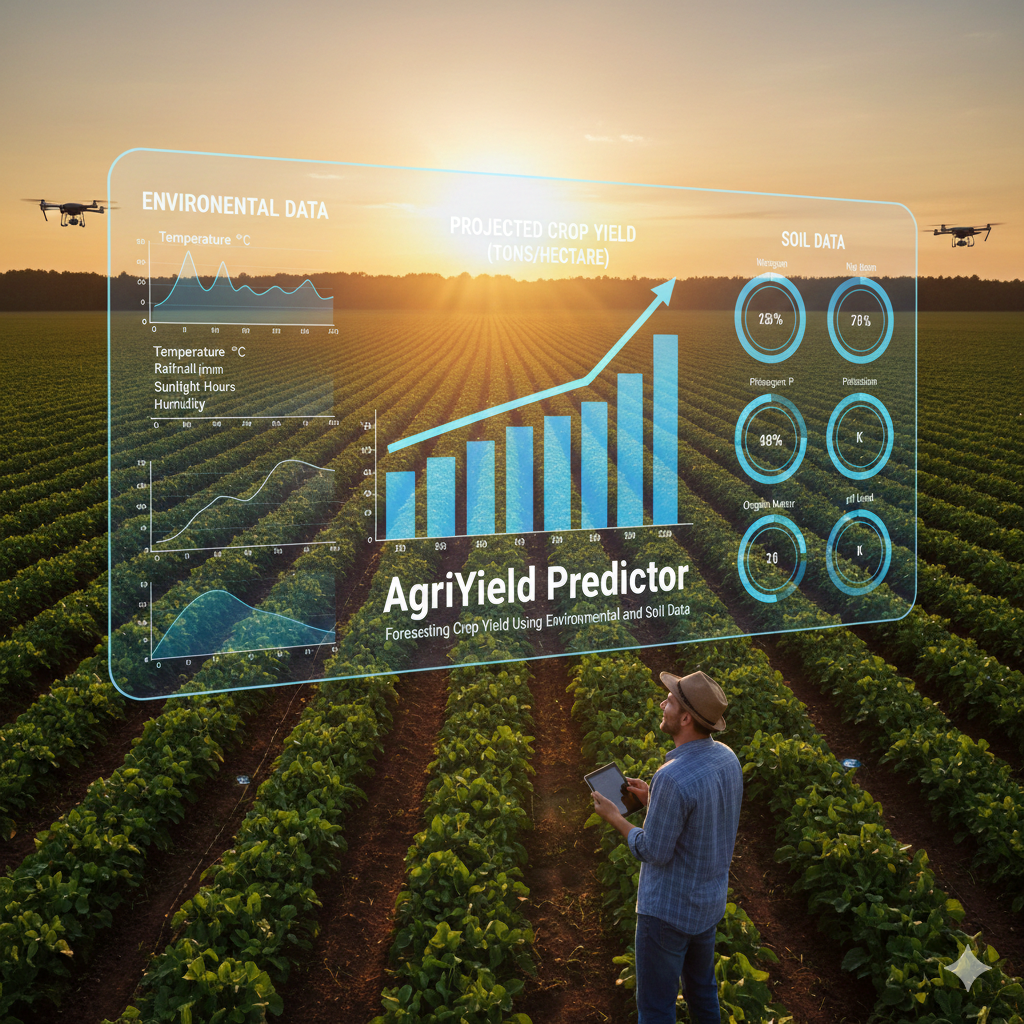

#**Milestone 1: Week 1 & 2 — Requirements & Dataset Preparation**

# **Project Overview & Scope**

**Project Objective**

Develop a machine learning model that can accurately predict crop yield (kg/hectare) for different crops grown in various regions, based on soil and environmental data.

**Project Scope**

This project will include:


| Task                       | Includes                                     | Tools Used          |
| -------------------------- | -------------------------------------------- | ------------------- |
| Data Collection & Cleaning | Integrating soil, crop, and climate datasets | Python (Pandas)     |
| EDA & Feature Engineering  | Trends, correlations, engineered features    | Matplotlib, Seaborn |
| Model Training             | Regression models                            | Sklearn, XGBoost    |
| Performance Evaluation     | RMSE, MAE, R² score                          | Sklearn metrics     |
| Deployment                 | Simple UI for farmers                        | Streamlit / Flask   |


####**Architectural diagram**

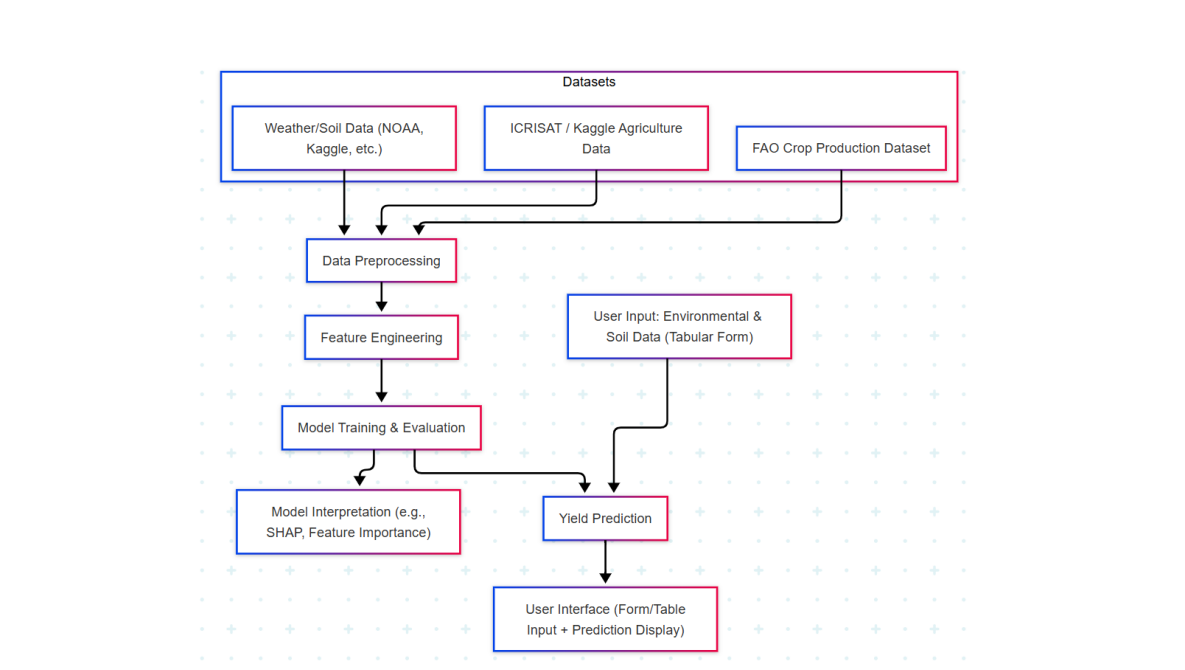

#**Import Required Libraries**


In [449]:
import numpy as np            # For numerical operations
import pandas as pd           # For data loading & preprocessing
import matplotlib.pyplot as plt  # For plotting graphs
import seaborn as sns            # For statistical visualizations

from sklearn.model_selection import train_test_split

#**Load Raw Datasets**

In [450]:
# Load the first dataset (FAOSTAT data)
fao = pd.read_csv("FAOSTAT_data.csv")

In [451]:
# Load the second dataset (Crop Recommendation data)
crop = pd.read_csv("Crop_recommendation.csv")

In [452]:
print("FAOSTAT shape:", fao.shape)
print("Crop Recommendation shape:", crop.shape)

FAOSTAT shape: (5940, 15)
Crop Recommendation shape: (2200, 8)


In [453]:
fao


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2000,2000,ha,3.444340e+05,A,Official figure,NaN
1,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2000,2000,kg/ha,4.840000e+02,A,Official figure,NaN
2,QCL,Crops and livestock products,356,India,5510,Production,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2000,2000,t,1.666920e+05,A,Official figure,NaN
3,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2001,2001,ha,5.692710e+05,A,Official figure,NaN
4,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2001,2001,kg/ha,4.303000e+02,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5935,QCL,Crops and livestock products,356,India,5412,Yield,111.0,Wheat,2022,2022,kg/ha,3.537300e+03,A,Official figure,NaN
5936,QCL,Crops and livestock products,356,India,5510,Production,111.0,Wheat,2022,2022,t,1.077421e+08,A,Official figure,NaN
5937,QCL,Crops and livestock products,356,India,5312,Area harvested,111.0,Wheat,2023,2023,ha,3.140072e+07,A,Official figure,NaN
5938,QCL,Crops and livestock products,356,India,5412,Yield,111.0,Wheat,2023,2023,kg/ha,3.520700e+03,A,Official figure,NaN


In [454]:
crop



,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [455]:
fao['Item'].unique()[:40]

array(['Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw',
       'Apples', 'Apricots', 'Areca nuts', 'Bananas', 'Barley',
       'Beans, dry', 'Cabbages', 'Cantaloupes and other melons',
       'Carrots and turnips', 'Cashew nuts, in shell', 'Cassava, fresh',
       'Castor oil seeds', 'Cauliflowers and broccoli', 'Cherries',
       'Chick peas, dry',
       'Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw',
       'Chillies and peppers, green (Capsicum spp. and Pimenta spp.)',
       'Cocoa beans', 'Coconuts, in shell', 'Coffee, green', 'Coir, raw',
       'Cucumbers and gherkins', 'Eggplants (aubergines)', 'Figs',
       'Ginger, raw', 'Grapes', 'Green garlic',
       'Groundnuts, excluding shelled', 'Jute, raw or retted',
       'Kenaf, and other textile bast fibres, raw or retted',
       'Lemons and limes', 'Lentils, dry', 'Lettuce and chicory',
       'Linseed', 'Maize (corn)', 'Mangoes, guavas and mangosteens',
       'Millet', 'Mushrooms a

In [456]:
for i in fao['Item'].unique():
    print(i)

Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw
Apples
Apricots
Areca nuts
Bananas
Barley
Beans, dry
Cabbages
Cantaloupes and other melons
Carrots and turnips
Cashew nuts, in shell
Cassava, fresh
Castor oil seeds
Cauliflowers and broccoli
Cherries
Chick peas, dry
Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw
Chillies and peppers, green (Capsicum spp. and Pimenta spp.)
Cocoa beans
Coconuts, in shell
Coffee, green
Coir, raw
Cucumbers and gherkins
Eggplants (aubergines)
Figs
Ginger, raw
Grapes
Green garlic
Groundnuts, excluding shelled
Jute, raw or retted
Kenaf, and other textile bast fibres, raw or retted
Lemons and limes
Lentils, dry
Lettuce and chicory
Linseed
Maize (corn)
Mangoes, guavas and mangosteens
Millet
Mushrooms and truffles
Natural rubber in primary forms
Nutmeg, mace, cardamoms, raw
Okra
Onions and shallots, dry (excluding dehydrated)
Oranges
Other beans, green
Other berries and fruits of the genus vaccinium n.e.c.
Other citrus fruit,

In [457]:
crop['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [458]:
print(crop.columns)

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')


In [459]:
crop = crop.rename(columns={'Item':'label'})

In [460]:
fao['Item'] = fao['Item'].str.split(r",|and")
fao = fao.explode('Item')

In [461]:
fao

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,Anise,2000,2000,ha,3.444340e+05,A,Official figure,NaN
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,badian,2000,2000,ha,3.444340e+05,A,Official figure,NaN
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,cori,2000,2000,ha,3.444340e+05,A,Official figure,NaN
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,er,2000,2000,ha,3.444340e+05,A,Official figure,NaN
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,cumin,2000,2000,ha,3.444340e+05,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5935,QCL,Crops and livestock products,356,India,5412,Yield,111.0,Wheat,2022,2022,kg/ha,3.537300e+03,A,Official figure,NaN
5936,QCL,Crops and livestock products,356,India,5510,Production,111.0,Wheat,2022,2022,t,1.077421e+08,A,Official figure,NaN
5937,QCL,Crops and livestock products,356,India,5312,Area harvested,111.0,Wheat,2023,2023,ha,3.140072e+07,A,Official figure,NaN
5938,QCL,Crops and livestock products,356,India,5412,Yield,111.0,Wheat,2023,2023,kg/ha,3.520700e+03,A,Official figure,NaN


# **CROP MAPPING**

In [462]:
#" other melons":"watermelon",

In [463]:
crop_mapping = {
    "Rice": "rice",
    "Maize (corn)": "maize",
    "Chick peas":"chickpea",
    "Pigeon peas":"pigeonpeas" ,
    "Beans":"mothbeans" ,
    "Lentils":"lentil" ,
    "Bananas":"banana" ,
    "Mangoes": "mango" ,
    "Grapes":"grapes" ,
    "Watermelons":"watermelon" ,
    "Cantaloupes ":"muskmelon",
    "Apples":"apple" ,
    "Oranges":"orange" ,
    "Papayas":"papaya" ,
    "Coconuts":"coconut" ,
    "Seed cotton":"cotton"  ,
    "Jute":"jute" ,
    "Coffee":"coffee"

}


In [464]:
len(crop_mapping)

18

In [465]:
fao['Crop']=fao['Item'].map(crop_mapping)

In [466]:
crop=crop.rename(columns={'label':'Crop'})

In [467]:
crop

,N,P,K,temperature,humidity,ph,rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [468]:
df_merged = crop.merge(
    fao,
    left_on="Crop",
    right_on="Crop",
    how="inner"
)

In [469]:
df_merged

,N,P,K,temperature,humidity,ph,rainfall,Crop,Domain Code,Domain,...,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Area harvested,113.0,Rice,2000,2000,ha,4.471200e+07,A,Official figure,NaN
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2000,2000,kg/ha,2.850800e+03,A,Official figure,NaN
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Production,113.0,Rice,2000,2000,t,1.274649e+08,A,Official figure,NaN
3,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Area harvested,113.0,Rice,2001,2001,ha,4.490000e+07,A,Official figure,NaN
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2001,2001,kg/ha,3.115800e+03,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129595,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2022,2022,kg/ha,7.742000e+02,E,Estimated value,NaN
129596,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Production,1610.0,Coffee,2022,2022,t,3.404065e+05,I,Value imputed by a receiving agency,NaN
129597,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Area harvested,1610.0,Coffee,2023,2023,ha,4.378620e+05,I,Value imputed by a receiving agency,NaN
129598,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2023,2023,kg/ha,7.602000e+02,E,Estimated value,NaN


In [470]:
fao['Crop'] = fao['Item'].map(crop_mapping)

In [471]:
crop = crop.rename(columns={'label': 'Crop'})

In [472]:
df_merged = crop.merge(
    fao,
    left_on="Crop",
    right_on="Crop",
    how="inner"
)

In [473]:
Production = ' Yield'

In [474]:
print("First 5 rows of df_merged:")
display(df_merged.head())

print("\nInformation about df_merged:")
display(df_merged.info())

First 5 rows of df_merged:


,N,P,K,temperature,humidity,ph,rainfall,Crop,Domain Code,Domain,...,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Area harvested,113.0,Rice,2000,2000,ha,44712000.0,A,Official figure,NaN
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2000,2000,kg/ha,2850.8,A,Official figure,NaN
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Production,113.0,Rice,2000,2000,t,127464896.0,A,Official figure,NaN
3,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Area harvested,113.0,Rice,2001,2001,ha,44900000.0,A,Official figure,NaN
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2001,2001,kg/ha,3115.8,A,Official figure,NaN



Information about df_merged:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129600 entries, 0 to 129599
Data columns (total 23 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   N                 129600 non-null  int64  
 1   P                 129600 non-null  int64  
 2   K                 129600 non-null  int64  
 3   temperature       129600 non-null  float64
 4   humidity          129600 non-null  float64
 5   ph                129600 non-null  float64
 6   rainfall          129600 non-null  float64
 7   Crop              129600 non-null  object 
 8   Domain Code       129600 non-null  object 
 9   Domain            129600 non-null  object 
 10  Area Code (M49)   129600 non-null  int64  
 11  Area              129600 non-null  object 
 12  Element Code      129600 non-null  int64  
 13  Element           129600 non-null  object 
 14  Item Code (CPC)   129600 non-null  float64
 15  Item              129600 non-null  obj

None

**Yield**


In [475]:
df_merged = df_merged[df_merged['Element'] == 'Yield']

In [476]:
df_merged

,N,P,K,temperature,humidity,ph,rainfall,Crop,Domain Code,Domain,...,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2000,2000,kg/ha,2850.8,A,Official figure,NaN
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2001,2001,kg/ha,3115.8,A,Official figure,NaN
7,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2002,2002,kg/ha,2616.3,A,Official figure,NaN
10,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2003,2003,kg/ha,3117.7,A,Official figure,NaN
13,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2004,2004,kg/ha,2975.6,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129586,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2019,2019,kg/ha,766.7,A,Official figure,NaN
129589,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2020,2020,kg/ha,712.6,A,Official figure,NaN
129592,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2021,2021,kg/ha,789.7,A,Official figure,NaN
129595,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2022,2022,kg/ha,774.2,E,Estimated value,NaN


In [477]:
df_merged['Crop'].value_counts()

,count
Crop,
rice,2400
maize,2400
chickpea,2400
pigeonpeas,2400
mothbeans,2400
lentil,2400
banana,2400
mango,2400
grapes,2400


In [478]:
df_merged

,N,P,K,temperature,humidity,ph,rainfall,Crop,Domain Code,Domain,...,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2000,2000,kg/ha,2850.8,A,Official figure,NaN
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2001,2001,kg/ha,3115.8,A,Official figure,NaN
7,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2002,2002,kg/ha,2616.3,A,Official figure,NaN
10,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2003,2003,kg/ha,3117.7,A,Official figure,NaN
13,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2004,2004,kg/ha,2975.6,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129586,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2019,2019,kg/ha,766.7,A,Official figure,NaN
129589,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2020,2020,kg/ha,712.6,A,Official figure,NaN
129592,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2021,2021,kg/ha,789.7,A,Official figure,NaN
129595,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2022,2022,kg/ha,774.2,E,Estimated value,NaN


In [479]:
df_merged=df_merged.drop(columns=['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Item Code (CPC)', 'Item','Year', 'Year Code','Unit', 'Flag', 'Flag Description', 'Note'], errors='ignore')

In [480]:
df_merged.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
Crop,0
Value,0


In [481]:
df_merged.duplicated().sum()

np.int64(500)

In [482]:
df_merged=df_merged.drop_duplicates().reset_index(drop=True)

In [483]:
df_merged



,N,P,K,temperature,humidity,ph,rainfall,Crop,Value
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2850.8
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3115.8
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2616.3
3,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3117.7
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2975.6
...,...,...,...,...,...,...,...,...,...
42695,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,766.7
42696,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,712.6
42697,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,789.7
42698,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,774.2


In [484]:
df_merged.describe()

,N,P,K,temperature,humidity,ph,rainfall,Value
count,42700.000000,42700.000000,42700.000000,42700.000000,42700.000000,42700.000000,42700.000000,42700.000000
mean,56.294052,54.340258,53.694895,25.737117,72.719113,6.457941,108.509465,9982.240515
std,37.980673,35.062166,54.655269,5.115147,20.802569,0.802278,58.306268,11818.064338
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,326.900000
25%,24.000000,28.000000,22.000000,23.089507,60.395233,6.000249,66.484904,938.500000
50%,44.000000,50.000000,35.000000,25.617074,80.525861,6.399434,97.100870,4322.300000
75%,91.000000,69.000000,52.000000,28.434307,90.493557,6.893509,145.929893,17654.100000
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117,44328.400000


In [485]:
df_merged.nunique()

,0
N,136
P,117
K,73
temperature,1800
humidity,1800
ph,1800
rainfall,1800
Crop,18
Value,424


In [486]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols=["N","P","K","temperature","humidity","ph","rainfall","Value"]

In [487]:
Q1=df_merged[numeric_cols].quantile(0.25)
Q3=df_merged[numeric_cols].quantile(0.75)
IQR=Q3-Q1

final_clean=df_merged[~((df_merged[numeric_cols]<(Q1-1.5*IQR))|
                        (df_merged[numeric_cols]>(Q3+1.5*IQR))).any(axis=1)]
print("Before:",df_merged.shape)
print("After:",final_clean.shape)
print("Removed Rows:",df_merged.shape[0]-final_clean.shape[0])

Before: (42700, 9)
After: (33551, 9)
Removed Rows: 9149


In [488]:
final_clean.head()

,N,P,K,temperature,humidity,ph,rainfall,Crop,Value
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2850.8
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3115.8
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2616.3
3,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3117.7
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2975.6


In [489]:
len(final_clean)

33551

In [490]:
final_clean['Crop'].value_counts()

,count
Crop,
banana,2400
lentil,2400
jute,2400
coffee,2400
coconut,2400
cotton,2400
watermelon,2400
maize,2300
muskmelon,2300


#**Data Cleaning & Formatting**

**Remove duplicate rows**

In [491]:
# Remove duplicate rows
fao.drop_duplicates(inplace=True)
crop.drop_duplicates(inplace=True)

**Check missing values**

In [492]:
# Check missing values
print("Missing values in FAOSTAT dataset:")
print(fao.isnull().sum())

print("Missing values in Crop Recommendation dataset:")
print(crop.isnull().sum())

Missing values in FAOSTAT dataset:
Domain Code             0
Domain                  0
Area Code (M49)         0
Area                    0
Element Code            0
Element                 0
Item Code (CPC)         0
Item                    0
Year Code               0
Year                    0
Unit                    0
Value                 434
Flag                    0
Flag Description        0
Note                10450
Crop                 9356
dtype: int64
Missing values in Crop Recommendation dataset:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
Crop           0
dtype: int64


In [493]:
# Show updated shapes
print("FAOSTAT shape:", fao.shape)
print("Crop Recommendation shape:", crop.shape)


FAOSTAT shape: (10652, 16)
Crop Recommendation shape: (2200, 8)


# **Explosion**

Before

In [494]:
# Create a safe copy of original data
df_explosion = fao.copy()

# Show row count before explosion
print("Rows BEFORE explosion:", df_explosion.shape[0])
0
# Show sample crop names before explosion
df_explosion[['Item']].head(10)


Rows BEFORE explosion: 10652


,Item
0,Anise
0,badian
0,cori
0,er
0,cumin
0,caraway
0,fennel
0,juniper berries
0,raw
1,Anise


Cleaning

In [495]:
# Create a copy so the original dataset remains unchanged
df_explosion = fao.copy()


In [496]:
# Standardize separators and text
df_explosion['Item_List'] = (
    df_explosion['Item']
    .str.lower()
    .str.replace(' and ', ',', regex=False)
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
)


In [497]:
# Split the standardized string into a list
df_explosion['Item_List'] = df_explosion['Item_List'].str.split(',')


In [498]:
# Explode the list so each crop gets its own row
df_exploded = df_explosion.explode('Item_List')


After

In [499]:
print("Rows AFTER explosion:", df_exploded.shape[0])

# Show sample rows AFTER explosion
df_exploded[['Item', 'Item_List']].head(10)


Rows AFTER explosion: 10652


,Item,Item_List
0,Anise,anise
0,badian,badian
0,cori,cori
0,er,er
0,cumin,cumin
0,caraway,caraway
0,fennel,fennel
0,juniper berries,juniper berries
0,raw,raw
1,Anise,anise


#**Merge Datasets**

In [500]:
df_merged = crop.merge(
    fao,
    left_on="Crop",
    right_on="Crop",
    how="inner"
)

In [501]:
df_merged


,N,P,K,temperature,humidity,ph,rainfall,Crop,Domain Code,Domain,...,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Area harvested,113.0,Rice,2000,2000,ha,4.471200e+07,A,Official figure,NaN
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2000,2000,kg/ha,2.850800e+03,A,Official figure,NaN
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Production,113.0,Rice,2000,2000,t,1.274649e+08,A,Official figure,NaN
3,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Area harvested,113.0,Rice,2001,2001,ha,4.490000e+07,A,Official figure,NaN
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2001,2001,kg/ha,3.115800e+03,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129595,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2022,2022,kg/ha,7.742000e+02,E,Estimated value,NaN
129596,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Production,1610.0,Coffee,2022,2022,t,3.404065e+05,I,Value imputed by a receiving agency,NaN
129597,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Area harvested,1610.0,Coffee,2023,2023,ha,4.378620e+05,I,Value imputed by a receiving agency,NaN
129598,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2023,2023,kg/ha,7.602000e+02,E,Estimated value,NaN


In [502]:
df_merged = df_merged[df_merged['Element'] == 'Production']

In [503]:
df_merged

,N,P,K,temperature,humidity,ph,rainfall,Crop,Domain Code,Domain,...,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Production,113.0,Rice,2000,2000,t,1.274649e+08,A,Official figure,NaN
5,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Production,113.0,Rice,2001,2001,t,1.399000e+08,A,Official figure,NaN
8,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Production,113.0,Rice,2002,2002,t,1.077303e+08,A,Official figure,NaN
11,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Production,113.0,Rice,2003,2003,t,1.327890e+08,A,Official figure,NaN
14,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Production,113.0,Rice,2004,2004,t,1.246971e+08,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129587,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Production,1610.0,Coffee,2019,2019,t,3.195000e+05,A,Official figure,NaN
129590,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Production,1610.0,Coffee,2020,2020,t,2.980000e+05,A,Official figure,NaN
129593,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Production,1610.0,Coffee,2021,2021,t,3.340000e+05,A,Official figure,NaN
129596,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Production,1610.0,Coffee,2022,2022,t,3.404065e+05,I,Value imputed by a receiving agency,NaN


In [504]:
df_merged['Crop'].value_counts()

,count
Crop,
rice,2400
maize,2400
chickpea,2400
pigeonpeas,2400
mothbeans,2400
lentil,2400
banana,2400
mango,2400
grapes,2400


In [505]:
len(crop_mapping)

18

In [506]:
df_merged=df_merged.drop(columns=['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Item Code (CPC)', 'Item','Year', 'Year Code','Unit', 'Flag', 'Flag Description', 'Note'])

In [507]:
df_merged

,N,P,K,temperature,humidity,ph,rainfall,Crop,Value
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1.274649e+08
5,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1.399000e+08
8,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1.077303e+08
11,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1.327890e+08
14,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1.246971e+08
...,...,...,...,...,...,...,...,...,...
129587,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,3.195000e+05
129590,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,2.980000e+05
129593,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,3.340000e+05
129596,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,3.404065e+05


In [508]:
df_merged.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
Crop,0
Value,0


In [509]:
df_merged.duplicated().sum()

np.int64(600)

In [510]:
df_merged=df_merged.drop_duplicates().reset_index(drop=True)

In [511]:
df_merged

,N,P,K,temperature,humidity,ph,rainfall,Crop,Value
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1.274649e+08
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1.399000e+08
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1.077303e+08
3,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1.327890e+08
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1.246971e+08
...,...,...,...,...,...,...,...,...,...
42595,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,3.195000e+05
42596,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,2.980000e+05
42597,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,3.340000e+05
42598,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,3.404065e+05


In [512]:
df_merged.describe()

,N,P,K,temperature,humidity,ph,rainfall,Value
count,42600.000000,42600.000000,42600.000000,42600.000000,42600.000000,42600.000000,42600.000000,4.260000e+04
mean,56.193005,54.474202,53.774648,25.750324,72.660051,6.456724,108.253987,1.564312e+07
std,37.953587,35.032819,54.690075,5.108830,20.817026,0.807079,58.380659,3.578103e+07
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,2.550000e+05
25%,24.000000,28.000000,22.000000,23.089749,60.277664,5.996932,66.293904,1.709460e+06
50%,44.000000,50.000000,35.000000,25.624466,80.499799,6.395258,96.515240,3.627500e+06
75%,91.000000,69.000000,52.000000,28.436471,90.452617,6.890760,145.417239,1.316020e+07
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117,2.067270e+08


In [513]:
df_merged.nunique()

,0
N,136
P,117
K,73
temperature,1800
humidity,1800
ph,1800
rainfall,1800
Crop,18
Value,426


# **Missing Value Analysis & Imputation**

In [514]:
# Fill missing values in FAOSTAT dataset
fao.fillna({
    col: fao[col].mean() if fao[col].dtype != 'object' else "Unknown"
    for col in fao.columns
}, inplace=True)



In [515]:
# Fill missing values in Crop Recommendation dataset
crop.fillna({
    col: crop[col].mean() if crop[col].dtype != 'object' else "Unknown"
    for col in crop.columns
}, inplace=True)

print(" Missing values handled successfully!")

 Missing values handled successfully!


In [516]:
#Check again after fixing
print("Remaining missing values in FAOSTAT:")
print(fao.isnull().sum())

print("\nRemaining missing values in Crop Recommendation:")
print(crop.isnull().sum())


Remaining missing values in FAOSTAT:
Domain Code         0
Domain              0
Area Code (M49)     0
Area                0
Element Code        0
Element             0
Item Code (CPC)     0
Item                0
Year Code           0
Year                0
Unit                0
Value               0
Flag                0
Flag Description    0
Note                0
Crop                0
dtype: int64

Remaining missing values in Crop Recommendation:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
Crop           0
dtype: int64


# **Save Cleaned Dataset for EDA**

#####**Save Cleaned Dataset**

In [517]:
fao
crop


,N,P,K,temperature,humidity,ph,rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [518]:
# Save cleaned FAOSTAT dataset
fao.to_csv("cleaned_faostat_data.csv", index=False)

# Save cleaned Crop Recommendation dataset
crop.to_csv("cleaned_crop_rec_data.csv", index=False)

print(" Cleaned datasets saved successfully!")


 Cleaned datasets saved successfully!


In [519]:
# show saved files
import os
print(os.listdir())


['.config', 'cleaned_faostat_data.csv', 'Crop_recommendation.csv', 'models', 'cleaned_crop_rec_data.csv', 'Final_Agri_Data.csv', 'FAOSTAT_data.csv', 'linear_regression_crop_yield_model.joblib', 'crop_label_encoder_columns.pkl', '.ipynb_checkpoints', 'sample_data']


#####**EDA (Exploratory Data Analysis)**

**Step 1: Dataset Overview**

In [520]:
# Dataset overview for FAOSTAT
print(" FAOSTAT Dataset Info:")
print(fao.info())

print(" FAOSTAT Describe:")
display(fao.describe())

# Dataset overview for Crop Recommendation
print(" Crop Recommendation Dataset Info:")
print(crop.info())

print(" Crop Recommendation Describe:")
display(crop.describe())



 FAOSTAT Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 10652 entries, 0 to 5939
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       10652 non-null  object 
 1   Domain            10652 non-null  object 
 2   Area Code (M49)   10652 non-null  int64  
 3   Area              10652 non-null  object 
 4   Element Code      10652 non-null  int64  
 5   Element           10652 non-null  object 
 6   Item Code (CPC)   10652 non-null  float64
 7   Item              10652 non-null  object 
 8   Year Code         10652 non-null  int64  
 9   Year              10652 non-null  int64  
 10  Unit              10652 non-null  object 
 11  Value             10652 non-null  float64
 12  Flag              10652 non-null  object 
 13  Flag Description  10652 non-null  object 
 14  Note              10652 non-null  object 
 15  Crop              10652 non-null  object 
dtypes: float64(2), int64(4)

,Area Code (M49),Element Code,Item Code (CPC),Year Code,Year,Value
count,10652.0,10652.000000,10652.000000,10652.000000,10652.000000,1.065200e+04
mean,356.0,5411.930154,1399.344168,2011.444142,2011.444142,3.364812e+06
std,0.0,81.832957,389.168018,6.901045,6.901045,1.897303e+07
min,356.0,5312.000000,111.000000,2000.000000,2000.000000,1.569000e+02
25%,356.0,5312.000000,1253.020000,2005.000000,2005.000000,8.531000e+03
50%,356.0,5412.000000,1359.900000,2011.000000,2011.000000,2.129484e+05
75%,356.0,5510.000000,1654.000000,2017.000000,2017.000000,1.564000e+06
max,356.0,5510.000000,1970.000000,2023.000000,2023.000000,4.905334e+08


 Crop Recommendation Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   Crop         2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None
 Crop Recommendation Describe:


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


**Step 2: Check Crop Distribution (Value Counts)**

In [521]:
print(" Top Crops in FAOSTAT:")
print(fao['Crop'].value_counts().head())

print(" Crop Labels in Recommendation Dataset:")
print(crop['Crop'].value_counts().head())

 Top Crops in FAOSTAT:
Crop
Unknown      9356
apple          72
banana         72
mothbeans      72
muskmelon      72
Name: count, dtype: int64
 Crop Labels in Recommendation Dataset:
Crop
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
Name: count, dtype: int64


**Step 3: Crop Production Analysis (Bar Chart)**

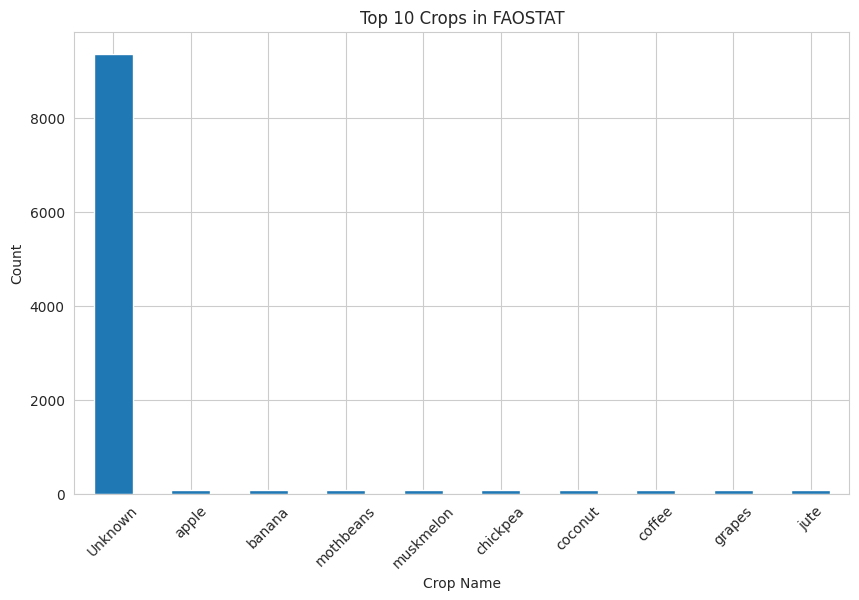

In [522]:
import matplotlib.pyplot as plt

# Count crops and show top 10
top_crops = fao['Crop'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_crops.plot(kind='bar')
plt.title("Top 10 Crops in FAOSTAT")
plt.xlabel("Crop Name")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

**Step 4: Production Over Years (Line Chart)**

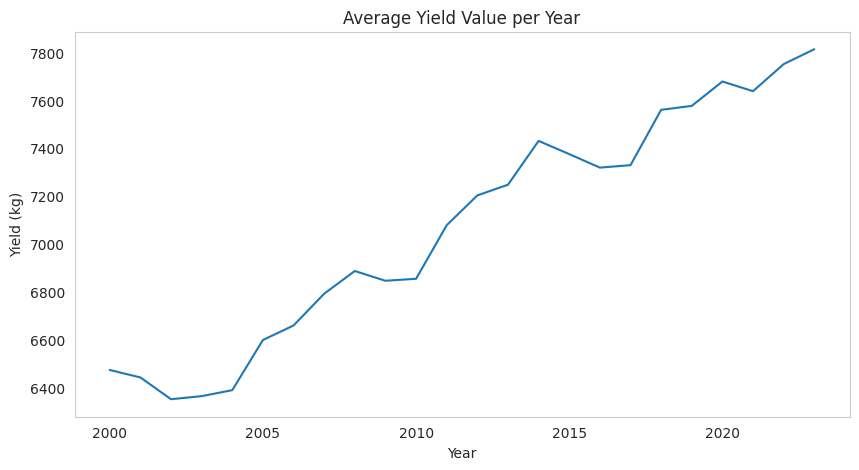

In [523]:
# Filter only Yield rows
production_df = fao[fao['Element'] == 'Yield']

# Group by Year and calculate average production
yearly_production = production_df.groupby('Year')['Value'].mean()

plt.figure(figsize=(10,5))
yearly_production.plot(kind='line')
plt.title("Average Yield Value per Year")
plt.xlabel("Year")
plt.ylabel("Yield (kg)")
plt.grid()
plt.show()


**Step 5: Correlation Heatmap (Crop Recommendation Dataset)**

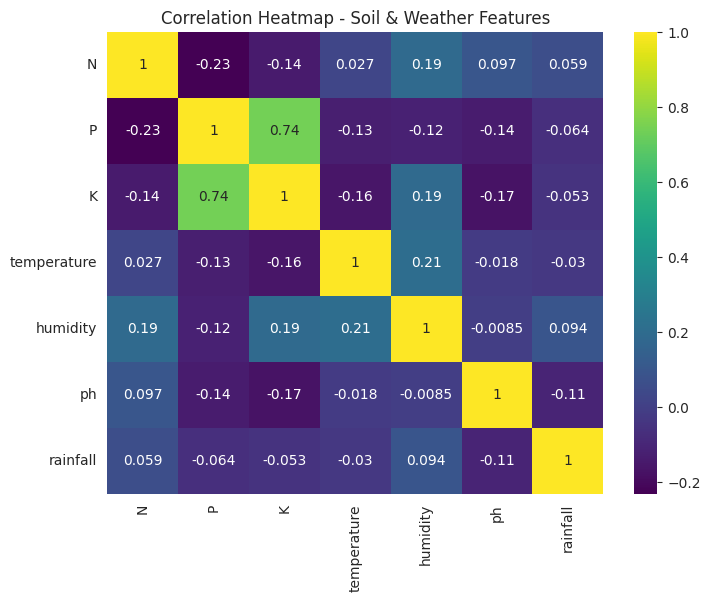

In [524]:
import seaborn as sns

plt.figure(figsize=(8,6))
# Exclude non-numeric columns (like 'crop') when calculating correlation
sns.heatmap(crop.drop(columns=['Crop']).corr(), annot=True, cmap="viridis")
plt.title("Correlation Heatmap - Soil & Weather Features")
plt.show()

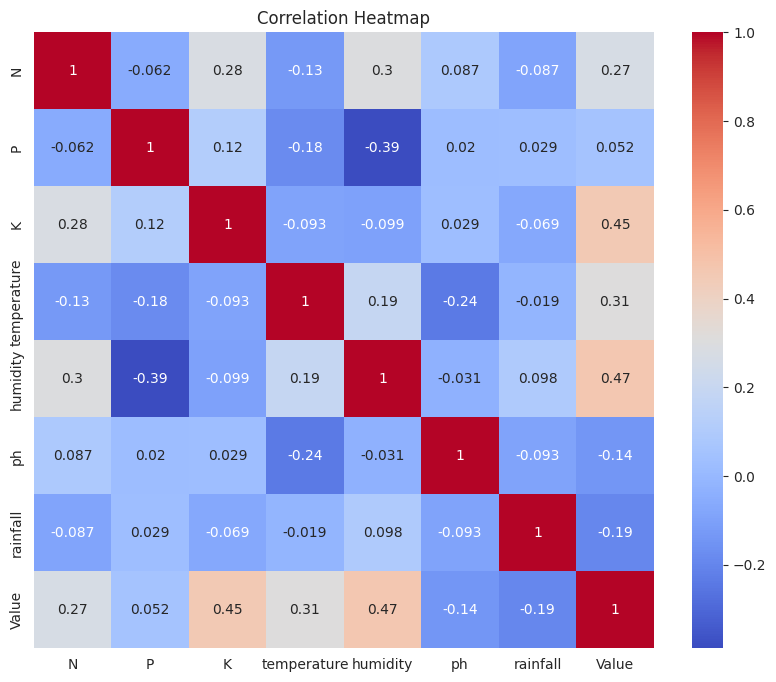

In [525]:
plt.figure(figsize=(10,8))
sns.heatmap(final_clean[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Step 6: Boxplot to Detect Outliers**

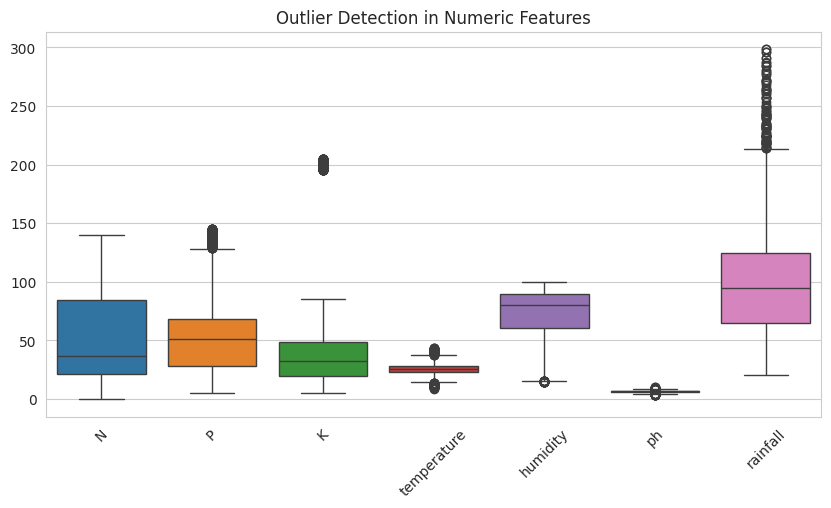

In [526]:
plt.figure(figsize=(10,5))
sns.boxplot(data=crop.select_dtypes(include=['float64','int64']))
plt.title("Outlier Detection in Numeric Features")
plt.xticks(rotation=45)
plt.show()


**Histograms for Numeric Features**

In [527]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Numeric features
num_cols_fao = fao.select_dtypes(include=['int64', 'float64']).columns
num_cols_crop = crop.select_dtypes(include=['int64', 'float64']).columns

print("FAOSTAT Numeric Columns:", list(num_cols_fao))
print("\nCrop Dataset Numeric Columns:", list(num_cols_crop))


FAOSTAT Numeric Columns: ['Area Code (M49)', 'Element Code', 'Item Code (CPC)', 'Year Code', 'Year', 'Value']

Crop Dataset Numeric Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


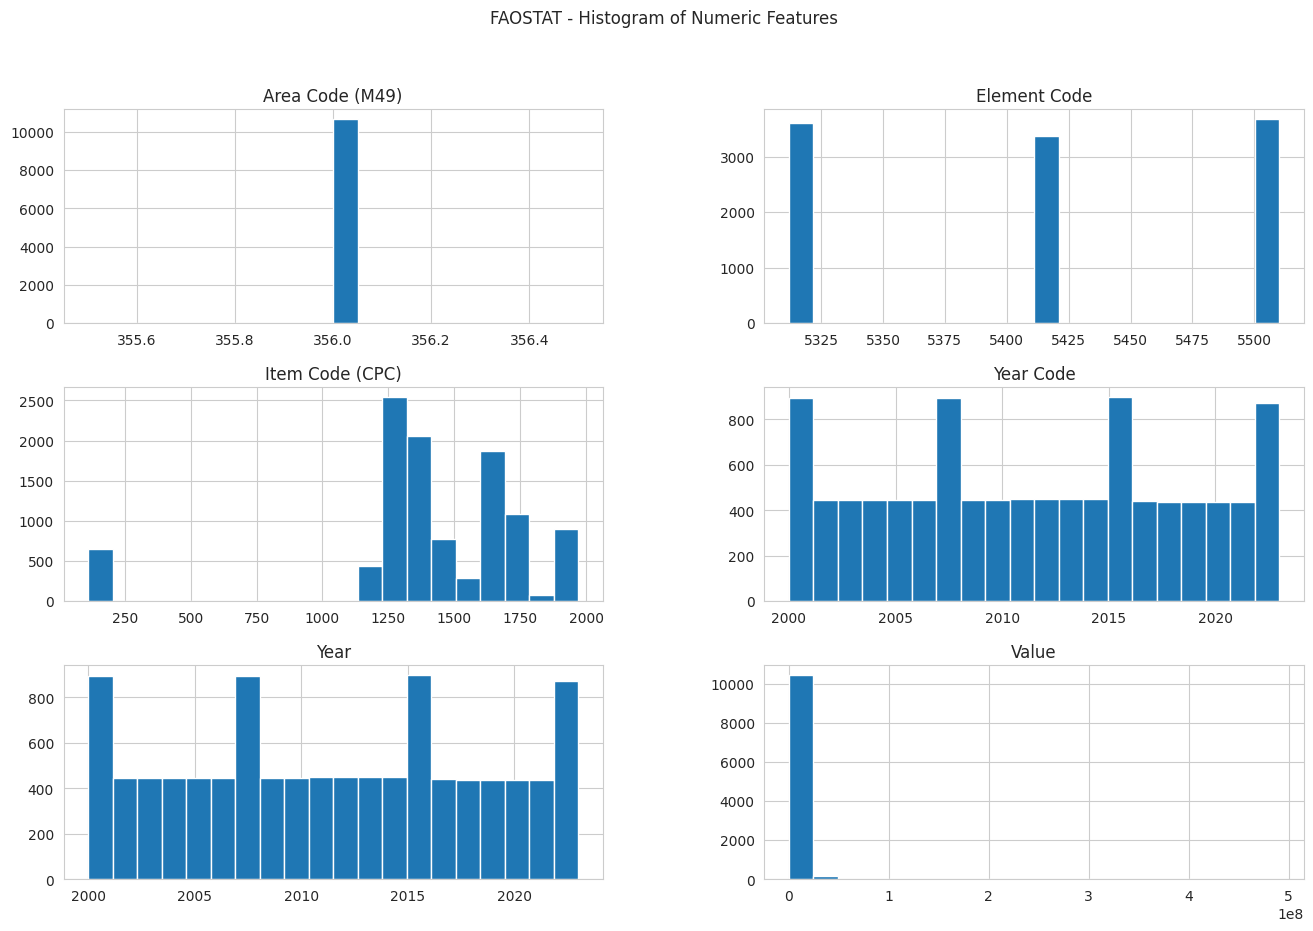

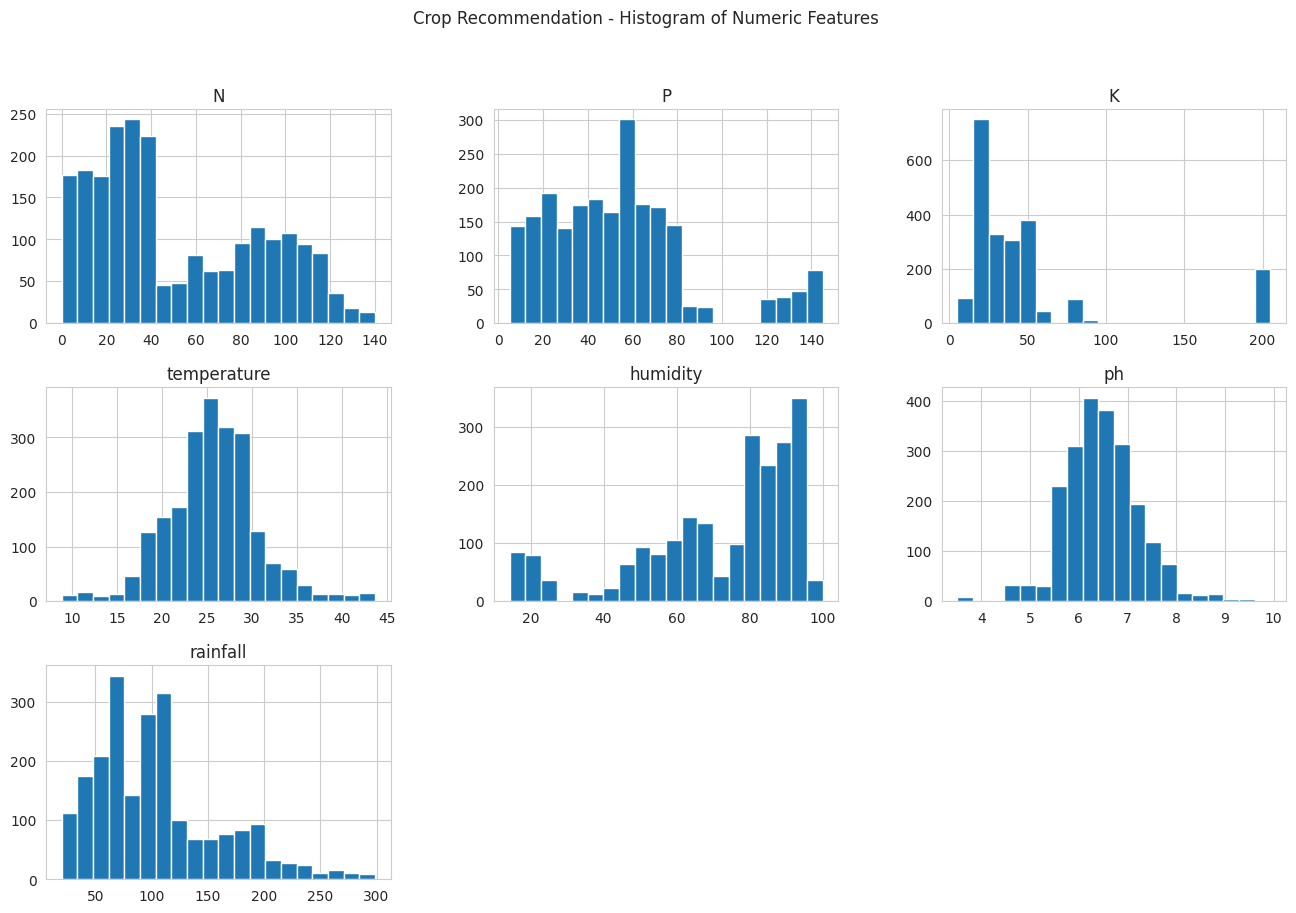

In [528]:
# Plot histograms for FAOSTAT
fao[num_cols_fao].hist(figsize=(16, 10), bins=20)
plt.suptitle("FAOSTAT - Histogram of Numeric Features")
plt.show()

# Plot histograms for Crop Recommendation dataset
crop[num_cols_crop].hist(figsize=(16, 10), bins=20)
plt.suptitle("Crop Recommendation - Histogram of Numeric Features")
plt.show()


**Boxplots for Outlier Detection**

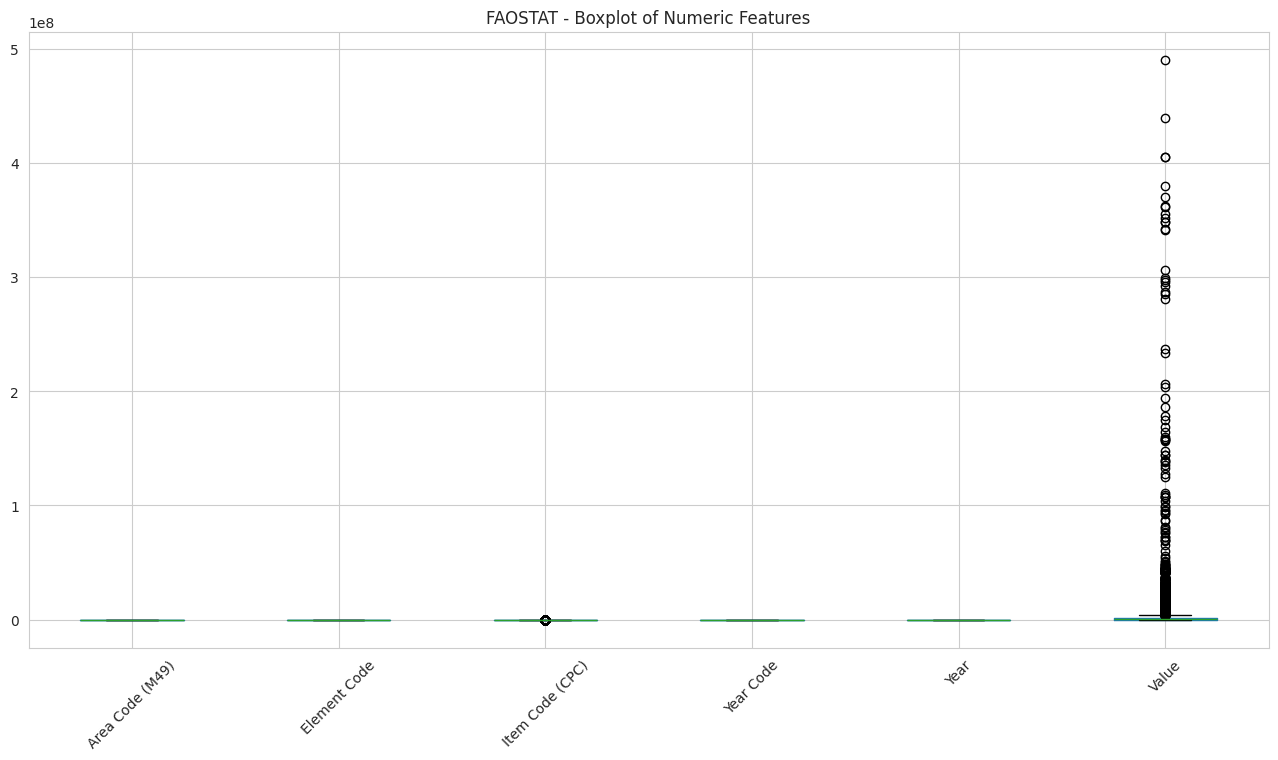

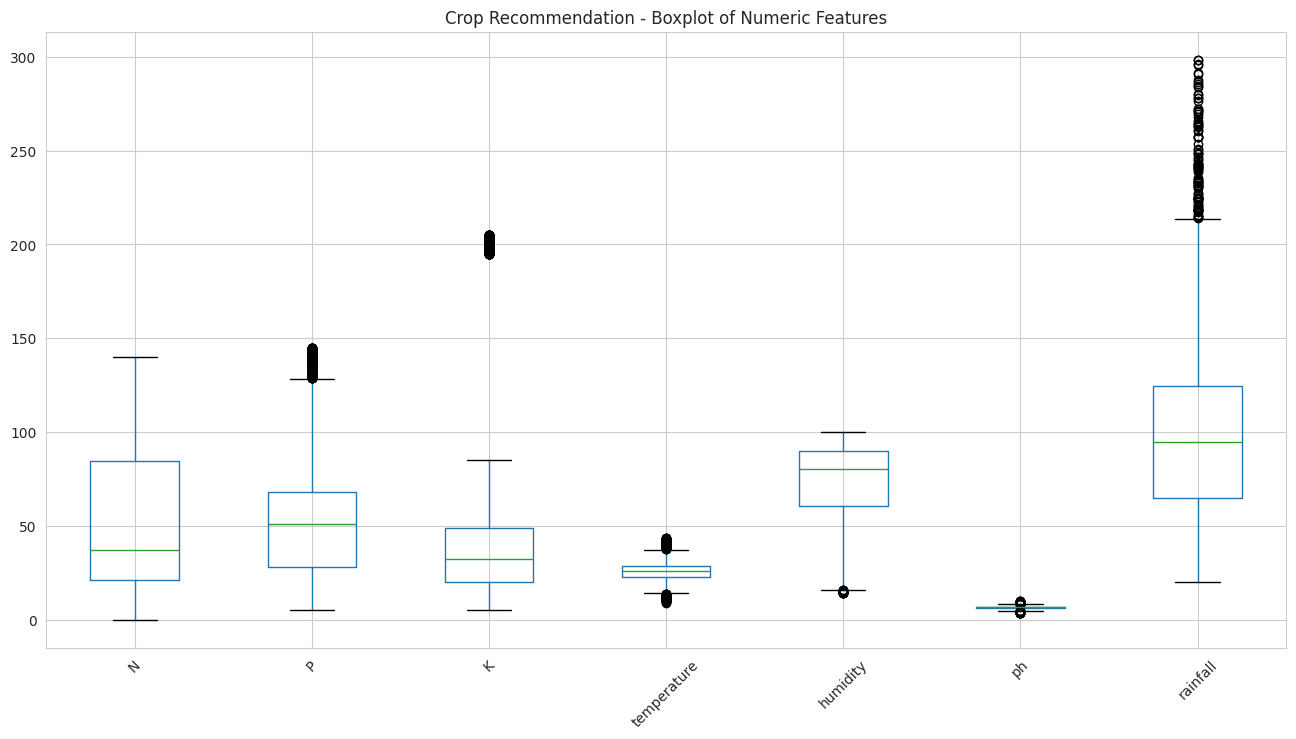

In [529]:
# Boxplots for FAOSTAT numeric features
plt.figure(figsize=(16, 8))
fao[num_cols_fao].boxplot()
plt.title("FAOSTAT - Boxplot of Numeric Features")
plt.xticks(rotation=45)
plt.show()

# Boxplots for Crop Recommendation dataset
plt.figure(figsize=(16, 8))
crop[num_cols_crop].boxplot()
plt.title("Crop Recommendation - Boxplot of Numeric Features")
plt.xticks(rotation=45)
plt.show()


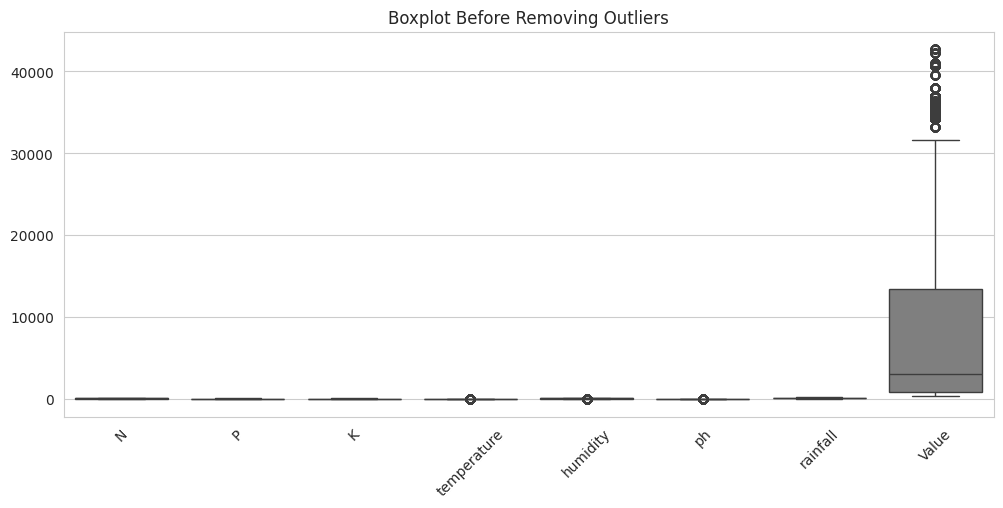

In [530]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=final_clean[numeric_cols])
plt.title("Boxplot Before Removing Outliers")
plt.xticks(rotation=45)
plt.show()

Average Crop Production


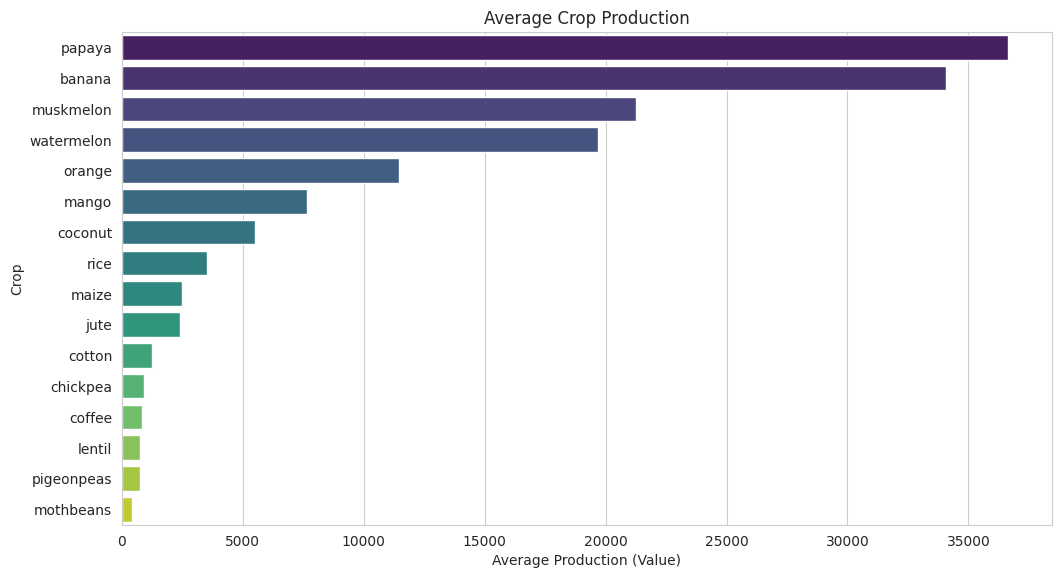

In [531]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define avg_vals (assuming it should be calculated from final_clean)
avg_vals = final_clean.groupby('Crop')['Value'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, max(6, len(avg_vals) * 0.4)))
sns.barplot(y=avg_vals.index, x=avg_vals.values, hue=avg_vals.index, palette='viridis', legend=False)
plt.xlabel('Average Production (Value)')
plt.ylabel('Crop')
plt.title('Average Crop Production')
plt.show()

In [532]:
len(final_clean)

33551

# **Milestone 2: Week 3 & 4 - EDA & Feature Engineering**

### **Performing Exploratory Data Analysis (EDA)**

In [533]:
final_clean = df_final_agri


In [534]:
df_final_agri = final_clean


 Performing Exploratory Data Analysis (EDA) on df_final_agri_encoded ---


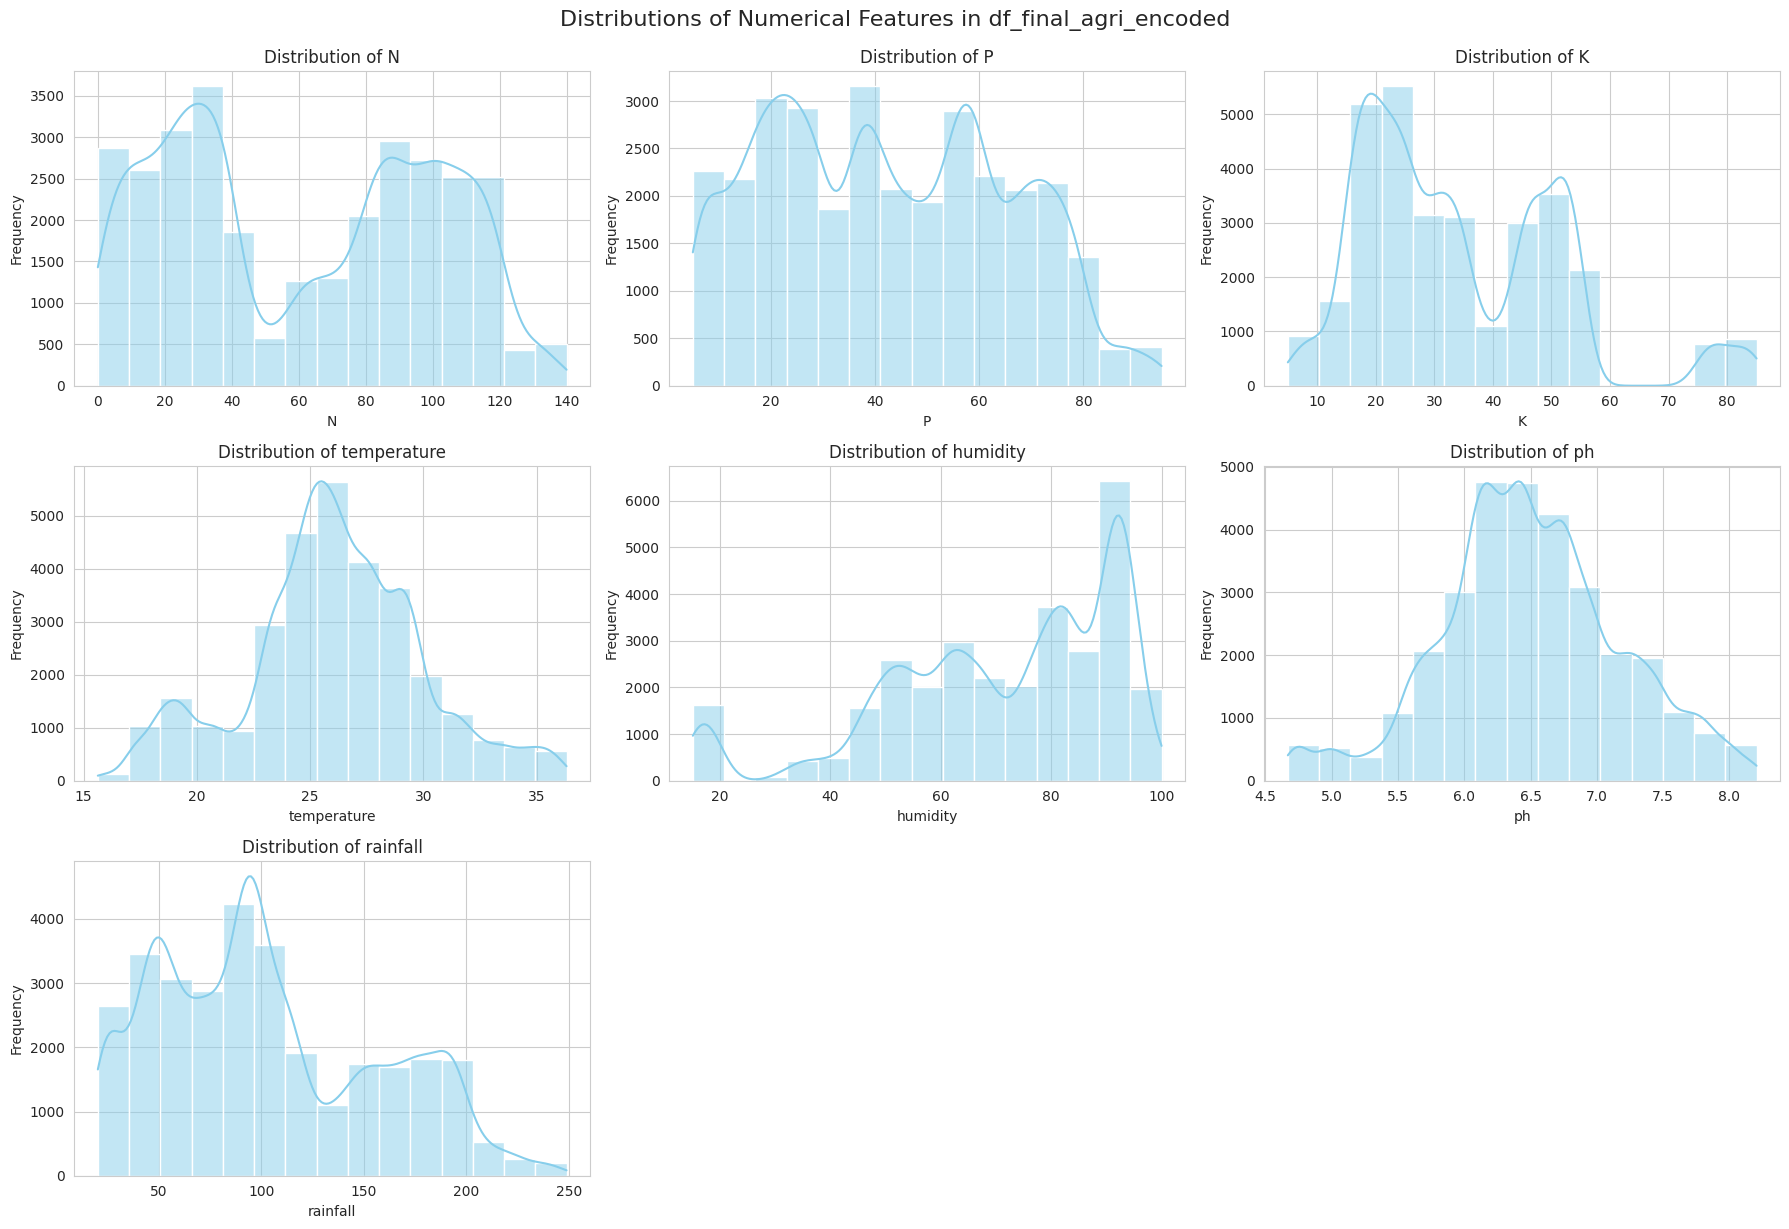


Correlation Matrix of Numerical Features (df_final_agri_encoded):


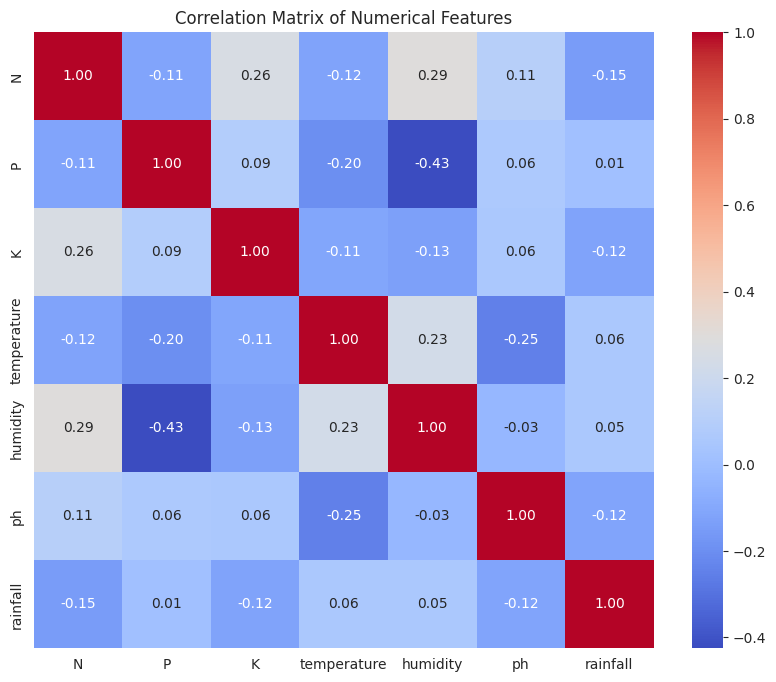


EDA Complete. Visualizations and Correlation Matrix generated.


In [535]:
print(' Performing Exploratory Data Analysis (EDA) on df_final_agri_encoded ---')

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming 'df_final_agri' is defined from previous steps. If not, this will still error.

# Dynamically determine which columns to one-hot encode based on existence
columns_to_encode = []
if 'Country' in df_final_agri.columns:
    columns_to_encode.append('Country')
if 'Crop' in df_final_agri.columns:
    columns_to_encode.append('Crop')

if columns_to_encode:
    df_final_agri_encoded = pd.get_dummies(df_final_agri, columns=columns_to_encode, drop_first=True)
else:
    print("Warning: Neither 'Country' nor 'Crop' columns found for encoding. Proceeding without encoding these columns.")
    df_final_agri_encoded = df_final_agri.copy()

# Set style for plots
sns.set_style("whitegrid")

# Define a list of potential numerical features
potential_numerical_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'Yield_kg_ha']

# Filter numerical_features_for_eda to include only columns present in df_final_agri_encoded
numerical_features_for_eda = [col for col in potential_numerical_features if col in df_final_agri_encoded.columns]

if not numerical_features_for_eda:
    print("Error: No numerical features found in df_final_agri_encoded for EDA.")
else:
    # Plotting distributions of numerical features
    plt.figure(figsize=(18, 12))
    for i, col in enumerate(numerical_features_for_eda):
        plt.subplot(3, 3, i + 1)
        sns.histplot(df_final_agri_encoded[col], kde=True, bins=15, color='skyblue')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
    plt.tight_layout()
    plt.suptitle('Distributions of Numerical Features in df_final_agri_encoded', y=1.02, fontsize=16)
    plt.show()

    # Plotting relationships between numerical features and 'Yield_kg_ha'
    # Only proceed if 'Yield_kg_ha' is in the numerical features list
    if 'Yield_kg_ha' in numerical_features_for_eda:
        plt.figure(figsize=(18, 12))
        # Exclude 'Yield_kg_ha' from independent variables for scatter plots against itself
        features_for_scatter = [col for col in numerical_features_for_eda if col != 'Yield_kg_ha']

        if features_for_scatter:
            for i, col in enumerate(features_for_scatter):
                plt.subplot(3, 3, i + 1)
                sns.scatterplot(x=df_final_agri_encoded[col], y=df_final_agri_encoded['Yield_kg_ha'], color='lightcoral', alpha=0.7)
                plt.title(f'{col} vs. Yield_kg_ha')
                plt.xlabel(col)
                plt.ylabel('Yield_kg_ha')
            plt.tight_layout()
            plt.suptitle('Relationships Between Numerical Features and Yield_kg_ha', y=1.02, fontsize=16)
            plt.show()
        else:
            print("Warning: No other numerical features available to plot against 'Yield_kg_ha'.")
    else:
        print("Warning: 'Yield_kg_ha' column not found, skipping scatter plots against it.")

    print('\nCorrelation Matrix of Numerical Features (df_final_agri_encoded):')
    # Calculate and display the correlation matrix for numerical features only
    if numerical_features_for_eda:
        corr_matrix_final = df_final_agri_encoded[numerical_features_for_eda].corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_matrix_final, annot=True, cmap='coolwarm', fmt=".2f")
        plt.title('Correlation Matrix of Numerical Features')
        plt.show()
    else:
        print("Warning: No numerical features to calculate correlation matrix.")

print('\nEDA Complete. Visualizations and Correlation Matrix generated.')

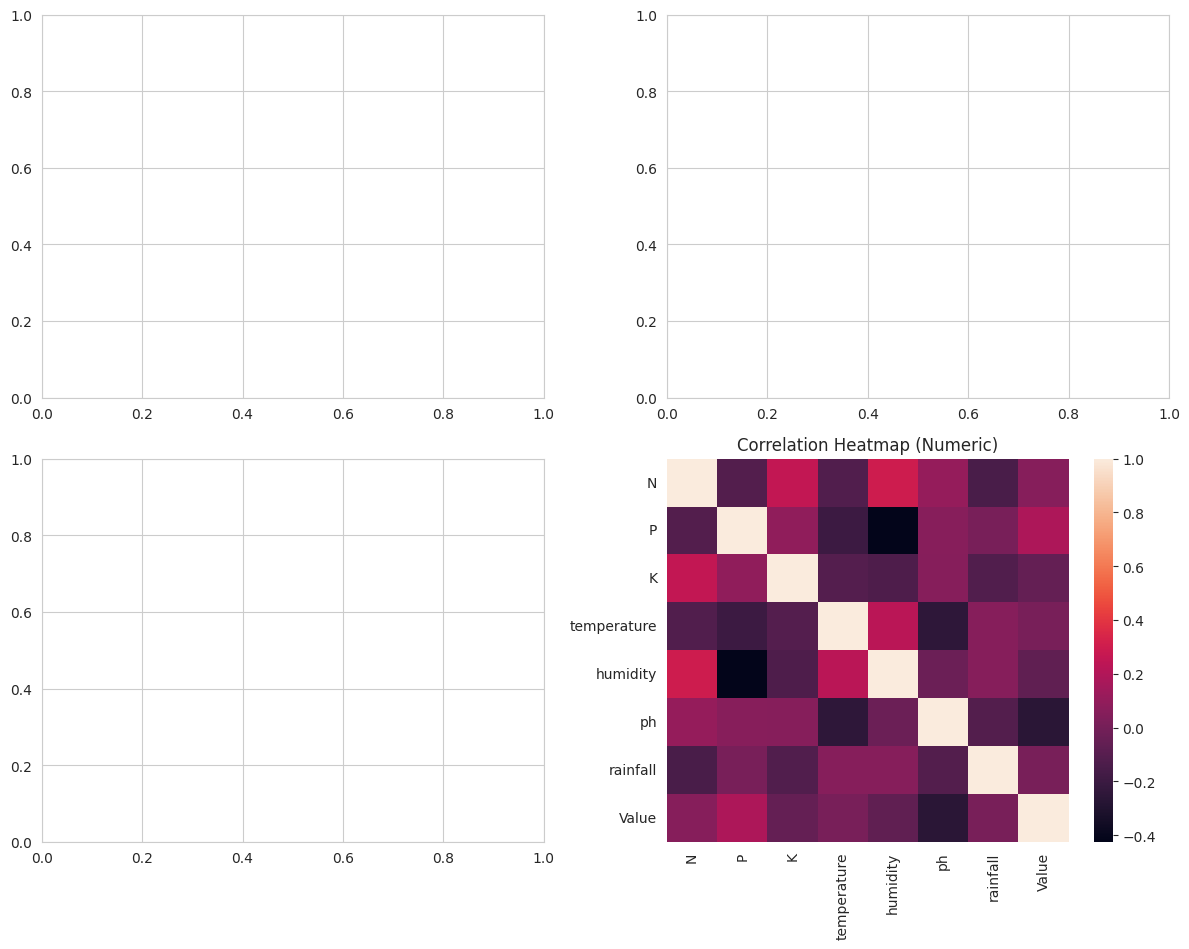

In [536]:
import seaborn as sns
import matplotlib.pyplot as plt

# 4) Correlation heatmap (numeric columns)
# Initialize a figure and a 2x2 grid of subplots (assuming this is part of a larger plot setup)
fig, axes = plt.subplots(2, 2, figsize=(12, 10)) # Added this line

numeric_df = df_final_agri.select_dtypes(include=['int64', 'float64'])
if numeric_df.shape[1] > 1:
    sns.heatmap(numeric_df.corr(), ax=axes[1, 1], annot=False)
    axes[1, 1].set_title("Correlation Heatmap (Numeric)")
else:
    axes[1, 1].text(0.5, 0.5, "Not enough numeric columns", ha='center')

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for title
plt.show()

In [537]:
print("Crops Included:", final_clean['Crop'].unique())
print()
print("Total No. of Crops Included:", len(final_clean['Crop'].unique()))

Crops Included: ['maize' 'chickpea' 'pigeonpeas' 'mothbeans' 'lentil' 'banana' 'mango'
 'watermelon' 'muskmelon' 'orange' 'papaya' 'coconut' 'cotton' 'jute'
 'coffee']

Total No. of Crops Included: 15


In [538]:
# Shape of the dataset
print("Dataset Shape:", final_clean.shape)

# Column names & data types
final_clean.info()

Dataset Shape: (30881, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 30881 entries, 2400 to 42599
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            30881 non-null  int64  
 1   P            30881 non-null  int64  
 2   K            30881 non-null  int64  
 3   temperature  30881 non-null  float64
 4   humidity     30881 non-null  float64
 5   ph           30881 non-null  float64
 6   rainfall     30881 non-null  float64
 7   Crop         30881 non-null  object 
 8   Value        30881 non-null  float64
dtypes: float64(5), int64(3), object(1)
memory usage: 2.4+ MB


In [539]:
# Summary statistics for numeric features
final_clean.describe()


,N,P,K,temperature,humidity,ph,rainfall,Value
count,30881.000000,30881.000000,30881.000000,30881.000000,30881.000000,30881.000000,30881.000000,3.088100e+04
mean,61.186620,42.488456,34.150287,26.056511,71.058399,6.497068,102.592353,7.422536e+06
std,39.346725,22.606106,17.118841,3.916020,20.765110,0.682353,53.585672,7.910445e+06
min,0.000000,5.000000,5.000000,15.632110,15.112796,4.669108,20.211267,2.550000e+05
25%,26.000000,23.000000,21.000000,23.964360,57.173770,6.088064,57.449421,1.368000e+06
50%,62.000000,41.000000,30.000000,26.030270,76.440486,6.458715,94.112133,3.626000e+06
75%,98.000000,60.000000,47.000000,28.523967,90.105225,6.925412,145.105065,1.204320e+07
max,140.000000,95.000000,85.000000,36.322681,99.981876,8.204862,248.859299,2.978000e+07


In [540]:
final_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30881 entries, 2400 to 42599
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            30881 non-null  int64  
 1   P            30881 non-null  int64  
 2   K            30881 non-null  int64  
 3   temperature  30881 non-null  float64
 4   humidity     30881 non-null  float64
 5   ph           30881 non-null  float64
 6   rainfall     30881 non-null  float64
 7   Crop         30881 non-null  object 
 8   Value        30881 non-null  float64
dtypes: float64(5), int64(3), object(1)
memory usage: 2.4+ MB


In [541]:
# Missing values count
final_clean.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
Crop,0
Value,0


# **Training Data**

In [542]:
numeric_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

In [543]:
print("--- Model Training ---")

print()
print("Preparing Training Data...")
print()


X = final_clean.drop(columns=['Value', 'Element'], errors='ignore')
y = final_clean['Value']


X = pd.get_dummies(X, columns=['Crop'], drop_first=False)
trained_columns = X.columns
print(f"Features Generated: {X.shape[1]}")
print()


print(X.columns.tolist())


--- Model Training ---

Preparing Training Data...

Features Generated: 22

['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'Crop_banana', 'Crop_chickpea', 'Crop_coconut', 'Crop_coffee', 'Crop_cotton', 'Crop_jute', 'Crop_lentil', 'Crop_maize', 'Crop_mango', 'Crop_mothbeans', 'Crop_muskmelon', 'Crop_orange', 'Crop_papaya', 'Crop_pigeonpeas', 'Crop_watermelon']


### Performing Train-Test Split

In [544]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("\n--- Train Test Split ---")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train Shape: {X_train.shape}")
print(f"Test Shape : {X_test.shape}")

print("\n--- Linear Regression Model Training ---")


lr_model = LinearRegression()


lr_model.fit(X_train, y_train)

print("Model Training Completed.")

print("\n--- Model Evaluation ---")


y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)


print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2 :", r2_score(y_test, y_test_pred))
print("MAE     :", mean_absolute_error(y_test, y_test_pred))
print("RMSE    :", np.sqrt(mean_squared_error(y_test, y_test_pred)))





--- Train Test Split ---
Train Shape: (24704, 22)
Test Shape : (6177, 22)

--- Linear Regression Model Training ---
Model Training Completed.

--- Model Evaluation ---
Train R2: 0.8515753967364961
Test R2 : 0.853963384830164
MAE     : 1869833.0748192347
RMSE    : 3021376.6902041705


# **Train Main Models**

### **• Random Forest Regressor**

In [545]:
from sklearn.ensemble import RandomForestRegressor

def run_random_forest_regressor(X_train, X_test, y_train, y_test):
    """
    Build and evaluate a Random Forest Regressor model.
    """
    print("Running Random Forest Regressor Model...")

    # Handle NaN values in y_train and y_test by imputing with the mean
    # This is necessary because scikit-learn models do not handle NaNs by default.
    y_train_cleaned = y_train.fillna(y_train.mean())
    y_test_cleaned = y_test.fillna(y_test.mean())

    # Initialize Random Forest Regressor with default parameters for now
    # Hyperparameter tuning can be done later.
    rf_model = RandomForestRegressor(random_state=42)

    # Use the common evaluation function
    metrics = evaluate_regression_model(
        model=rf_model,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train_cleaned, # Use cleaned y_train
        y_test=y_test_cleaned    # Use cleaned y_test
    )

    return rf_model, metrics

random_forest_model, random_forest_metrics = run_random_forest_regressor(
    X_train, X_test, y_train, y_test
)

Running Random Forest Regressor Model...
Model Name   : RandomForestRegressor
MAE          : 1964810.0060
MSE          : 10178639469506.8418
RMSE         : 3190398.0111
R² Score     : 0.8372
--------------------------------------------------


Top 10 Feature Importances for Random Forest Regressor:


,Feature,Importance
7,Crop_banana,0.253298
14,Crop_maize,0.238381
15,Crop_mango,0.208155
11,Crop_cotton,0.138915
9,Crop_coconut,0.098790
8,Crop_chickpea,0.027505
0,N,0.010720
13,Crop_lentil,0.006250
4,humidity,0.005624
6,rainfall,0.002178


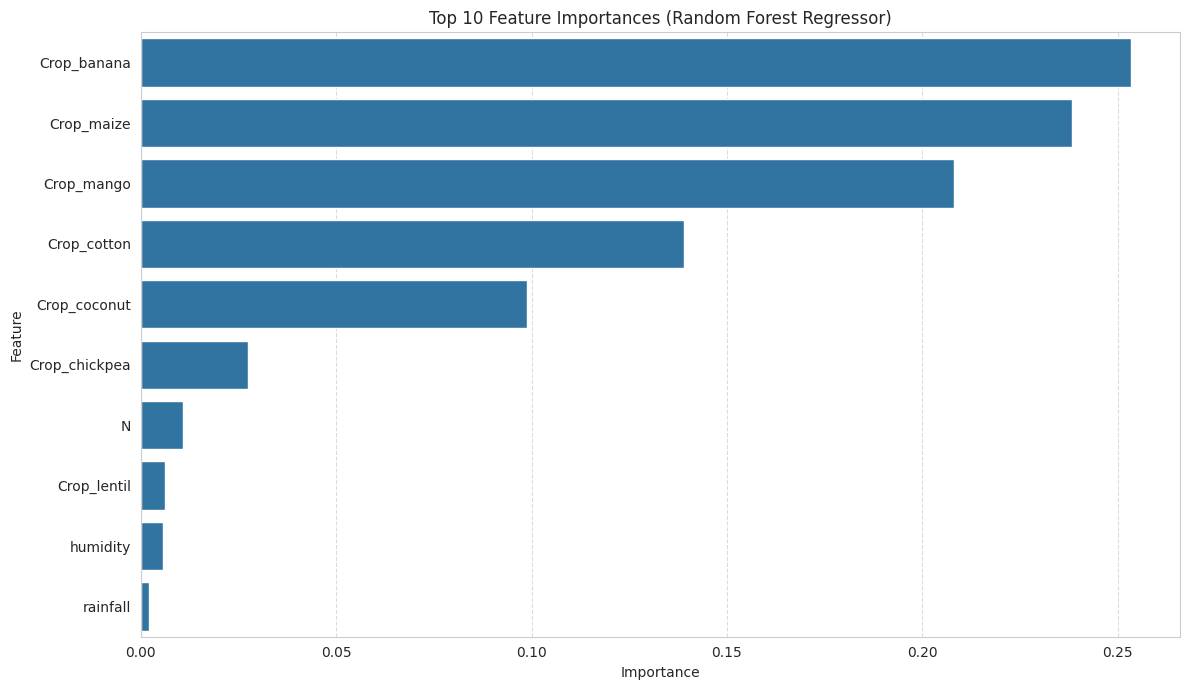

In [546]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Random Forest model
feature_importances = random_forest_model.feature_importances_

# Get feature names from X_train (assuming X_train is a DataFrame)
feature_names = X_train.columns

# Create a DataFrame for better visualization and sorting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top N most important features (e.g., top 10)
num_features_to_display = 10
print(f"Top {num_features_to_display} Feature Importances for Random Forest Regressor:")
display(importance_df.head(num_features_to_display))

# Visualize feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(num_features_to_display))
plt.title(f'Top {num_features_to_display} Feature Importances (Random Forest Regressor)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [547]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("\n--- Train Test Split ---")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train Shape: {X_train.shape}")
print(f"Test Shape : {X_test.shape}")

print("\n--- Linear Regression Model Training ---")


lr_model = LinearRegression()


lr_model.fit(X_train, y_train)

print("Model Training Completed.")

print("\n--- Model Evaluation ---")


y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)


print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2 :", r2_score(y_test, y_test_pred))
print("MAE     :", mean_absolute_error(y_test, y_test_pred))
print("RMSE    :", np.sqrt(mean_squared_error(y_test, y_test_pred)))


--- Train Test Split ---
Train Shape: (24704, 22)
Test Shape : (6177, 22)

--- Linear Regression Model Training ---
Model Training Completed.

--- Model Evaluation ---
Train R2: 0.8515753967364961
Test R2 : 0.853963384830164
MAE     : 1869833.0748192347
RMSE    : 3021376.6902041705


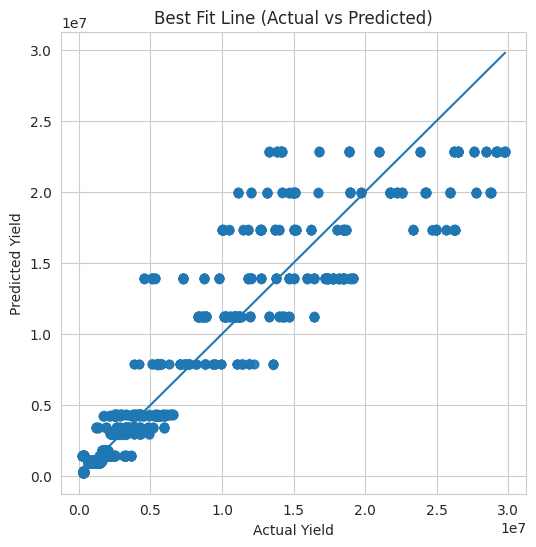

In [548]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Best Fit Line (Actual vs Predicted)")
plt.show()


In [549]:
import joblib

print(f"Saving object type: {type(lr_model)}")

joblib.dump(lr_model, "linear_regression_crop_yield_model.joblib", compress=3)


joblib.dump(trained_columns, "crop_label_encoder_columns.pkl")

print(" Model successfully saved!")

Saving object type: <class 'sklearn.linear_model._base.LinearRegression'>
 Model successfully saved!


In [550]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


print("\nRandom Forest Model Training")


rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)


rf_model.fit(X_train, y_train)

print("Random Forest Training Completed.")


Random Forest Model Training
Random Forest Training Completed.


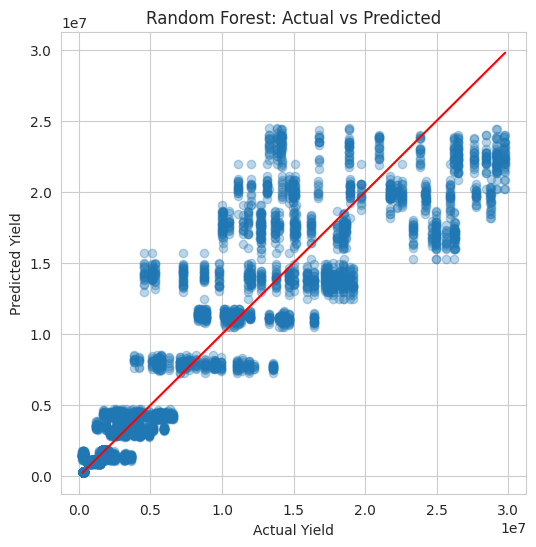

In [551]:
plt.figure(figsize=(6,6))

# Calculate predictions on the test set
rf_test_pred = rf_model.predict(X_test)

plt.scatter(y_test, rf_test_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r')
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

### **• XGBoost Regressor**

In [552]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import numpy as np

lr_model = LinearRegression()

lr_rmse_scores = -cross_val_score(
    lr_model,
    X,
    y,
    cv=3,
    scoring="neg_root_mean_squared_error"
)

print("Linear Regression RMSE:", lr_rmse_scores.mean())


Linear Regression RMSE: 7056901.312906434


In [553]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("\n--- XGBoost Model Training ---")


xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)


xgb_model.fit(X_train, y_train)

print("XGBoost Training Completed.")


--- XGBoost Model Training ---
XGBoost Training Completed.


In [554]:
print("\n--- XGBoost Evaluation ---")

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Metrics
print("Train R2:", r2_score(y_train, y_train_pred_xgb))
print("Test R2 :", r2_score(y_test, y_test_pred_xgb))
print("MAE     :", mean_absolute_error(y_test, y_test_pred_xgb))
print("RMSE    :", np.sqrt(mean_squared_error(y_test, y_test_pred_xgb)))



--- XGBoost Evaluation ---
Train R2: 0.8531839397214451
Test R2 : 0.8398527561291251
MAE     : 1946416.6376130201
RMSE    : 3163979.99997656


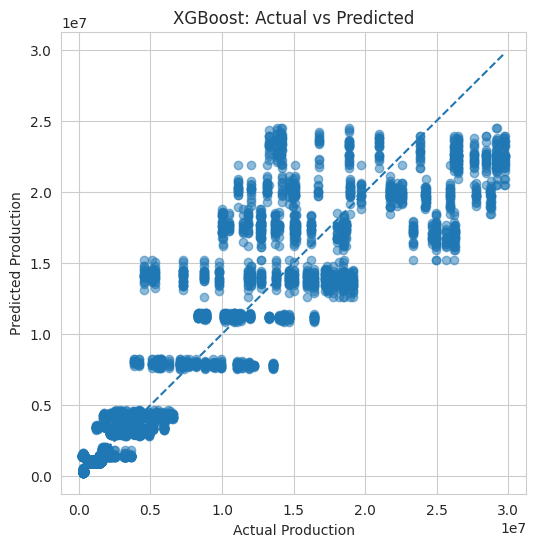

In [555]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_xgb, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--')
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

In [560]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

param_grid_xgb = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1],
    'colsample_bytree': [0.8, 0.9, 1]
}

In [565]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np


In [566]:
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

param_grid_xgb = {
    'n_estimators': [200, 300],
    'max_depth': [5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}


In [567]:
grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(X_train, y_train)

print("✅ XGBoost GridSearch Completed")


Fitting 5 folds for each of 32 candidates, totalling 160 fits
✅ XGBoost GridSearch Completed


In [568]:
best_xgb = grid_xgb.best_estimator_

print("Best XGBoost Parameters:")
print(grid_xgb.best_params_)

print("Best CV R² Score:")
print(grid_xgb.best_score_)


Best XGBoost Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best CV R² Score:
0.8419908212946284


In [569]:
xgb_train_pred = best_xgb.predict(X_train)
xgb_test_pred = best_xgb.predict(X_test)

print("\n--- Tuned XGBoost ---")
print("Train R2:", r2_score(y_train, xgb_train_pred))
print("Test R2 :", r2_score(y_test, xgb_test_pred))
print("MAE     :", mean_absolute_error(y_test, xgb_test_pred))
print("RMSE    :", np.sqrt(mean_squared_error(y_test, xgb_test_pred)))



--- Tuned XGBoost ---
Train R2: 0.8527703198888987
Test R2 : 0.845764556596655
MAE     : 1914147.0884707381
RMSE    : 3105032.0572749795


In [571]:
import joblib
joblib.dump(best_xgb, "xgboost_crop_yield_model.joblib")
print(" XGBoost model saved")


 XGBoost model saved


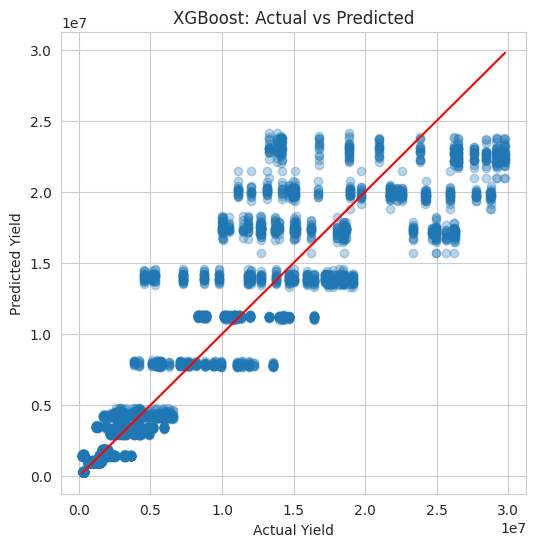

In [572]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, xgb_test_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r')
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

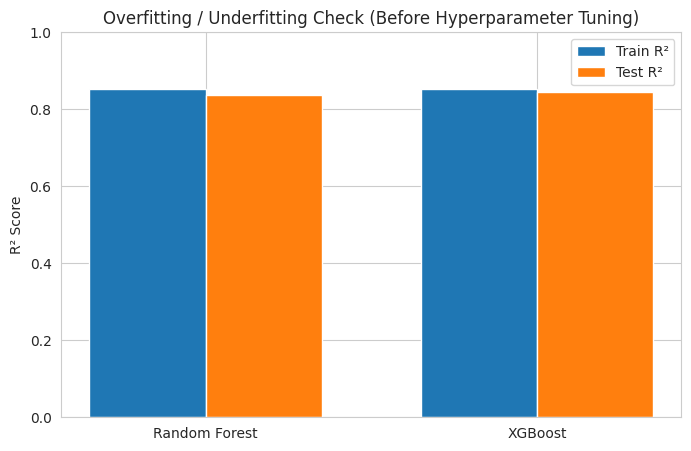

In [580]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Make predictions using the Random Forest model
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

models = ['Random Forest', 'XGBoost']

train_scores = [
    r2_score(y_train, rf_train_pred),
    r2_score(y_train, xgb_train_pred) # Using xgb_train_pred based on notebook state
]

test_scores = [
    r2_score(y_test, rf_test_pred),
    r2_score(y_test, xgb_test_pred) # Using xgb_test_pred based on notebook state
]

x = np.arange(len(models))
bar_width = 0.35

plt.figure(figsize=(8,5))

# Train
plt.bar(x - bar_width/2, train_scores, bar_width, label='Train R²')

# Test
plt.bar(x + bar_width/2, test_scores, bar_width, label='Test R²')


plt.xticks(x, models)
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.title("Overfitting / Underfitting Check (Before Hyperparameter Tuning)")
plt.legend()

plt.show()

# **Target Variable Distribution (Crop Yield)**

**Distribution Plot (Histogram + KDE)**

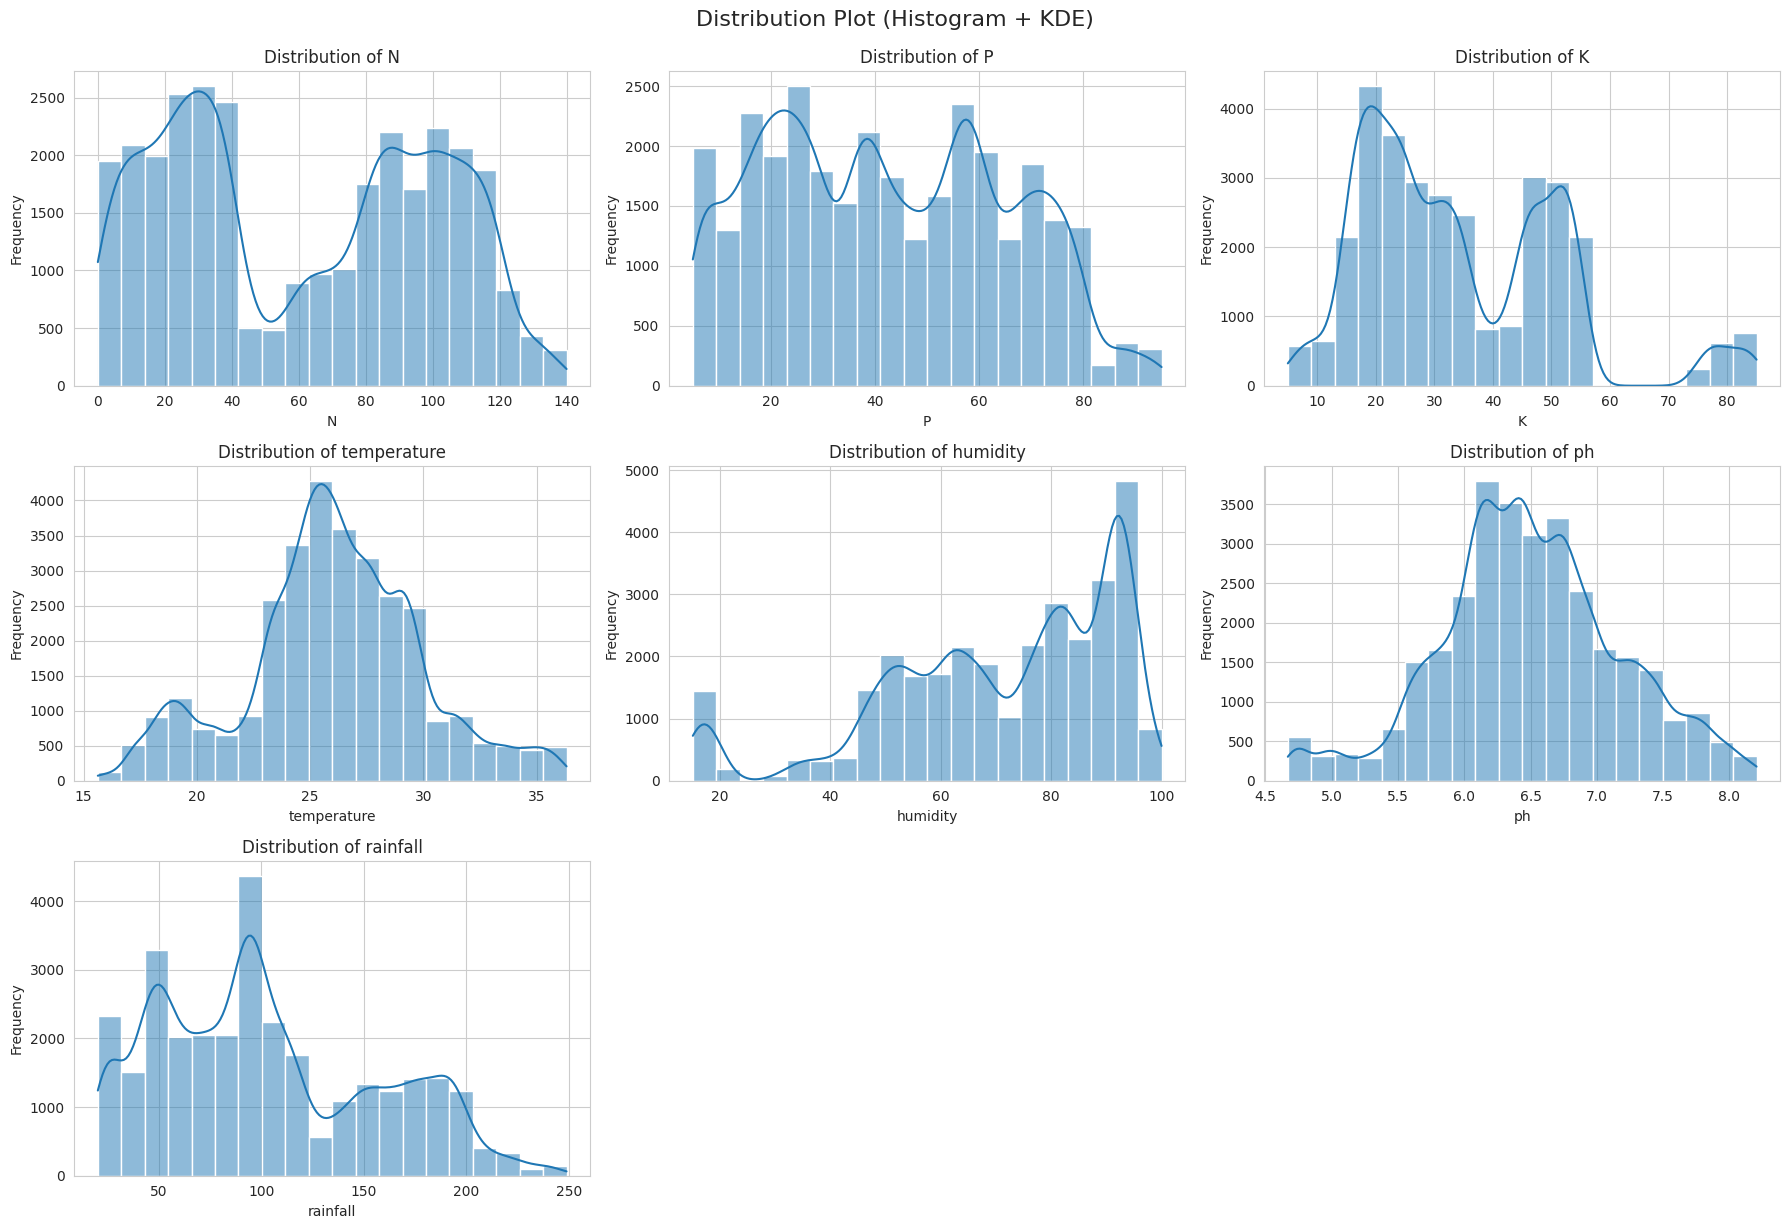

In [557]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assign
final_clean = df_final_agri

# Numerical columns to plot
# Dynamically check for column existence to prevent KeyError
potential_numerical_features = [
    'N', 'P', 'K',
    'temperature', 'humidity',
    'ph', 'rainfall',
    'Yield_kg_ha' # Assuming this is the desired target column, verify its exact name
]

numerical_features = [col for col in potential_numerical_features if col in final_clean.columns]

if not numerical_features:
    print("Error: No numerical features found in final_clean to plot.")
else:
    # Set style
    sns.set_style("whitegrid")

    # Create distribution plots
    plt.figure(figsize=(18, 12))

    for i, col in enumerate(numerical_features):
        plt.subplot(3, 3, i + 1)
        sns.histplot(
            final_clean[col],
            bins=20,
            kde=True
        )
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.suptitle(
        'Distribution Plot (Histogram + KDE)',
        fontsize=16,
        y=1.02
    )
    plt.show()


# **SVM MODELS**

In [558]:
# --- Imports ---
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error

# ---------- 1. Split features and target ----------
target_col = 'Value'   # change if your yield column is different
X_fao = fao.drop(columns=[target_col])
y_fao = fao[target_col]

# ---------- 2. Identify column types ----------
cat_cols_fao = X_fao.select_dtypes(include=['object']).columns.tolist()
num_cols_fao = X_fao.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("FAOSTAT - Categorical columns:", cat_cols_fao)
print("FAOSTAT - Numeric columns:", num_cols_fao)

# ---------- 3. Preprocessing (One-Hot + Scaling) ----------
preprocessor_fao = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_fao),
        ('num', StandardScaler(), num_cols_fao)
    ]
)

# ---------- 4. Define SVR model ----------
# RBF kernel is common for non-linear problems
svr_model = SVR(
    kernel='rbf',
    C=10.0,
    epsilon=0.1
)

# ---------- 5. Build full pipeline ----------
fao_svr_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor_fao),
    ('model', svr_model)
])

# ---------- 6. Train-test split ----------
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_fao, y_fao, test_size=0.2, random_state=42
)

# Handle NaNs in yf_train and corresponding Xf_train before fitting
if yf_train.isnull().any():
    valid_indices_train = yf_train.dropna().index
    Xf_train_cleaned = Xf_train.loc[valid_indices_train]
    yf_train_cleaned = yf_train.loc[valid_indices_train]
    print(f"Removed {len(yf_train) - len(yf_train_cleaned)} NaN values from yf_train for training.")
else:
    Xf_train_cleaned = Xf_train
    yf_train_cleaned = yf_train

# ---------- 7. Fit model ----------
fao_svr_pipeline.fit(Xf_train_cleaned, yf_train_cleaned)

# Handle NaNs in yf_test and corresponding Xf_test before evaluation
if yf_test.isnull().any():
    valid_indices_test = yf_test.dropna().index
    Xf_test_cleaned = Xf_test.loc[valid_indices_test]
    yf_test_cleaned = yf_test.loc[valid_indices_test]
    print(f"Removed {len(yf_test) - len(yf_test_cleaned)} NaN values from yf_test for scoring.")
else:
    Xf_test_cleaned = Xf_test
    yf_test_cleaned = yf_test

# ---------- 8. Evaluate ----------
y_pred = fao_svr_pipeline.predict(Xf_test_cleaned)

r2 = r2_score(yf_test_cleaned, y_pred)
mae = mean_absolute_error(yf_test_cleaned, y_pred)

print(f"SVR Yield Prediction - R² Score : {r2:.3f}")
print(f"SVR Yield Prediction - MAE      : {mae:.3f}")

FAOSTAT - Categorical columns: ['Domain Code', 'Domain', 'Area', 'Element', 'Item', 'Unit', 'Flag', 'Flag Description', 'Note', 'Crop']
FAOSTAT - Numeric columns: ['Area Code (M49)', 'Element Code', 'Item Code (CPC)', 'Year Code', 'Year']
SVR Yield Prediction - R² Score : -0.030
SVR Yield Prediction - MAE      : 3708714.002


In [559]:
svr_linear = SVR(kernel='linear', C=1.0)
fao_svr_pipeline.set_params(model=svr_linear)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Domain Code', 'Domain',
                                                   'Area', 'Element', 'Item',
                                                   'Unit', 'Flag',
                                                   'Flag Description', 'Note',
                                                   'Crop']),
                                                 ('num', StandardScaler(),
                                                  ['Area Code (M49)',
                                                   'Element Code',
                                                   'Item Code (CPC)',
                                                   'Year Code', 'Year'])])),
                ('model', SVR(kernel='linear'))])

In [ ]:
check_model_on_input(
    n=90,
    p=42,
    k=43,
    temp=20.8,
    hum=82.0,
    ph=6.5,
    rain=202.9,
    crop="Coffee"
)


 Predicted Yield for Coffee: 280452.62 Kilogram


In [ ]:
check_model_on_input(
    n=90,
    p=42,
    k=43,
    temp=20.8,
    hum=82.0,
    ph=6.5,
    rain=202.9,
    crop="orange"
)


 Predicted Yield for orange: 3553294.95 Kilogram


In [582]:
import joblib

def get_available_crops():
    cols = joblib.load("crop_label_encoder_columns.pkl")
    crops = [c.replace('Crop_', '').capitalize() for c in cols if c.startswith('Crop_')]
    print("🌱 Crops avaliable is:")
    print("-" * 40)
    for i, crop in enumerate(sorted(crops), 1):
        print(f"{i}. {crop}")
    print("-" * 40)
    print(f"Total Crops: {len(crops)}")
get_available_crops()

🌱 Crops avaliable is:
----------------------------------------
1. Banana
2. Chickpea
3. Coconut
4. Coffee
5. Cotton
6. Jute
7. Lentil
8. Maize
9. Mango
10. Mothbeans
11. Muskmelon
12. Orange
13. Papaya
14. Pigeonpeas
15. Watermelon
----------------------------------------
Total Crops: 15


## **CLASSIFICATION MODEL**

In [583]:
import pandas as pd
import numpy as np
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

In [585]:
data = pd.read_csv("Crop_recommendation.csv")

print("\nShape:", data.shape)
print("\nColumns:\n", data.columns.tolist())


Shape: (2200, 8)

Columns:
 ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


In [586]:
print("\nMissing Values:\n", data.isnull().sum())
print("\nDuplicate Rows:", data.duplicated().sum())

data = data.drop_duplicates().reset_index(drop=True)


Missing Values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate Rows: 0


# **STATISTICAL SUMMARY**

In [587]:
print(data.describe())
print("\nUnique Values per Column:\n")
print(data.nunique())

                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    28.561654    89.948771   
max     140.000000   145.000000   205.000000    43.675493    99.981876   

                ph     rainfall  
count  2200.000000  2200.000000  
mean      6.469480   103.463655  
std       0.773938    54.958389  
min       3.504752    20.211267  
25%       5.971693    64.551686  
50%       6.425045    94.867624  
75%       6.923643   124.267508  
max       9.935091   298.560117  

Unique Values per Column:


In [588]:
print("\n========== CROP DISTRIBUTION ==========")
print(data["label"].value_counts())


========== CROP DISTRIBUTION ==========
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


# **OUTLIER DETECTION AND REMOVAL(IQR)**

In [590]:
numeric_cols = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

Q1 = data[numeric_cols].quantile(0.25)
Q3 = data[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

clean_data = data[
    ~((data[numeric_cols] < (Q1 - 1.5 * IQR)) |
      (data[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
]
print("Before:", data.shape)
print("After :", clean_data.shape)

Before: (2200, 8)
After : (1768, 8)


**Feature & Target Split**

In [591]:
X = clean_data.drop(columns=["label"])
y = clean_data["label"]

**Encode Target**

In [592]:

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nEncoded Classes:\n", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))


Encoded Classes:
 {'banana': np.int64(0), 'blackgram': np.int64(1), 'chickpea': np.int64(2), 'coconut': np.int64(3), 'coffee': np.int64(4), 'cotton': np.int64(5), 'jute': np.int64(6), 'kidneybeans': np.int64(7), 'lentil': np.int64(8), 'maize': np.int64(9), 'mango': np.int64(10), 'mothbeans': np.int64(11), 'mungbean': np.int64(12), 'muskmelon': np.int64(13), 'orange': np.int64(14), 'papaya': np.int64(15), 'pigeonpeas': np.int64(16), 'pomegranate': np.int64(17), 'rice': np.int64(18), 'watermelon': np.int64(19)}


**Train-Test Split**

In [593]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

**ML** **PIPELINE**

In [594]:
pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]
)

**Hyperparameter Optimization**

In [597]:
param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [None, 20, 40],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

print("\nBest Parameters:\n", grid.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters:
 {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}


# **MODEL EVALUATION**

In [598]:
y_pred = best_model.predict(X_test)

print("\n========== MODEL PERFORMANCE ==========")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


========== MODEL PERFORMANCE ==========
Accuracy: 0.9915254237288136

Classification Report:

              precision    recall  f1-score   support

      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        11
     coconut       1.00      1.00      1.00        17
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.92      1.00      0.96        12
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        17
      papaya       1.00      1.00      1

**FEATURE IMPORTANCE**

In [599]:
importances = best_model.named_steps["model"].feature_importances_
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)
print(feature_importance)

       Feature  Importance
6     rainfall    0.221884
4     humidity    0.220707
2            K    0.172895
1            P    0.132766
0            N    0.114390
3  temperature    0.080434
5           ph    0.056924


In [600]:
joblib.dump(best_model, "crop_classifier.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [601]:
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    model = joblib.load("crop_classifier.pkl")
    encoder = joblib.load("label_encoder.pkl")

    input_data = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    encoded_pred = model.predict(input_data)[0]
    return encoder.inverse_transform([encoded_pred])[0]

**SAMPLE PREDICTION**

In [602]:
if __name__ == "__main__":
    result = predict_crop(
        N=90,
        P=42,
        K=43,
        temperature=20.87,
        humidity=82.00,
        ph=6.50,
        rainfall=202.93
    )
    print("\nPredicted Crop:", result)



Predicted Crop: rice


In [604]:
if __name__ == "__main__":
    result = predict_crop(
        N=90,
        P=70,
        K=43,
        temperature=20.87,
        humidity=82.00,
        ph=6.50,
        rainfall=202.93
    )
    print("\nPredicted Crop:", result)



Predicted Crop: rice
